In [1]:
import sys


sys.path.insert(0, "src")

In [2]:
from src.pipeline.document import extract_pages
from pathlib import Path

pages_to_extract = [2, 27, 28, 30, 38, 46, 50, 52]
ZOOM = 5

In [3]:
image_dir = Path("data/")
image_dir.mkdir(parents=True, exist_ok=True)

pages_names = [f"page_{i}.png" for i in pages_to_extract]
peding_pages = []
for page_name, page_number in zip(pages_names, pages_to_extract):
    if not (image_dir / page_name).exists():
        peding_pages.append(page_number)

if peding_pages:
    print(f"Extracting pages {peding_pages}...")
    extracted_pages = extract_pages(
        pdf_path=Path("data/2507.21509v1.pdf"),
        output_dir=Path("data/"),
        pages_to_extract=peding_pages,
    )

In [4]:
import cv2


from typing import Any
from pathlib import Path
import numpy as np


def load_rgb_image(image_path: Path) -> np.ndarray:
    """
    Load an image from the given path and convert it to RGB format.

    Args:
        image_path (Path): Path to the image file.

    Returns:
        np.ndarray: Image in RGB format.
    """
    image_bgr: np.ndarray | None = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise FileNotFoundError(f"Image not found at {image_path}")
    image_rgb: np.ndarray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    return image_rgb


page_image_path: Path = Path("data/page_30.png")
page_image: np.ndarray = load_rgb_image(page_image_path)

In [5]:

from src.pipeline.document.detection.backends import (
    DoclayoutYoloBackend,
    YoloDoclaynetBackend,
)
from src.pipeline.document.detection.backends.base import BaseDetectionBackend

def print_label_mapping(title: str, backend: type[BaseDetectionBackend]) -> None:
    print(f"\n{title.center(40)}")
    print(f"{'Original Label':<25} {'Unified Label':<25}")
    print("-" * 45)
    for original_label in backend.get_original_labels():
        unified_label = backend.normalize_label(original_label)
        print(f"{original_label:<25} {unified_label:<25}")

print_label_mapping("DoclayoutYoloBackend", DoclayoutYoloBackend)
print_label_mapping("YoloDoclaynetBackend", YoloDoclaynetBackend)


          DoclayoutYoloBackend          
Original Label            Unified Label            
---------------------------------------------
title                     title                    
plain text                text                     
figure                    picture                  
figure_caption            picture_caption          
table_caption             table_caption            
formula_caption           formula_caption          
table                     table                    
table_footnote            table_footnote           
isolate_formula           formula                  
abandon                   other                    

          YoloDoclaynetBackend          
Original Label            Unified Label            
---------------------------------------------
caption                   caption                  
footnote                  footnote                 
title                     title                    
formula                   formula           

In [6]:
from src.pipeline.document import Detector
from src.config.settings import Settings
from src.pipeline.document.detection.backends import DetectionBackendEnum

DEFAULT_DOCLAYOUT_YOLO_PATH = Path("models/doclayout_yolo_docstructbench_imgsz1024.pt")
DEFAULT_YOLO_DOCLAYNET_PATH = Path("models/yolov12l-doclaynet.pt")
settings = Settings(Path("settings.toml"))

detector = Detector(
    model_path=str(DEFAULT_DOCLAYOUT_YOLO_PATH),
    backend=DetectionBackendEnum.DOCLAYOUT_YOLO,
    settings=settings,
)

detections_doclayout = detector.parse_layout(page_image)

2025-08-13 23:38:44.237 | INFO     | src.pipeline.document.detection.backends.doclayout_yolo:__init__:34 | Initializing DoclayoutYoloBackend with model: models\doclayout_yolo_docstructbench_imgsz1024.pt
2025-08-13 23:38:44.541 | INFO     | src.pipeline.document.detection.backends.doclayout_yolo:__init__:36 | DoclayoutYoloBackend initialized successfully



0: 1024x800 1 title, 4 plain texts, 2 abandons, 1 figure, 1 figure_caption, 1 table, 1 table_caption, 1573.0ms
Speed: 8.8ms preprocess, 1573.0ms inference, 1.7ms postprocess per image at shape (1, 3, 1024, 800)


2025-08-13 23:38:47.786 | INFO     | src.pipeline.document.detection.backends.doclayout_yolo:detect:105 | Layout detection completed: 11 objects found
2025-08-13 23:38:47.788 | INFO     | src.pipeline.document.detection.backends.doclayout_yolo:detect:110 | Removed 0 duplicates


In [7]:
settings = Settings(Path("settings.toml"))

detector = Detector(
    model_path=str(DEFAULT_YOLO_DOCLAYNET_PATH),
    backend=DetectionBackendEnum.YOLO_DOCLAYNET,
    settings=settings,
)

detections_doclaynet = detector.parse_layout(page_image)

2025-08-13 23:38:47.797 | INFO     | src.pipeline.document.detection.backends.yolo_doclaynet:__init__:36 | Initializing YoloDoclaynetBackend with model: models\yolov12l-doclaynet.pt
2025-08-13 23:38:48.061 | INFO     | src.pipeline.document.detection.backends.yolo_doclaynet:__init__:39 | YoloDoclaynetBackend initialized successfully



0: 1024x800 1 Page-footer, 1 Page-header, 1 Picture, 3 Section-headers, 1 Table, 7 Texts, 1234.6ms
Speed: 7.8ms preprocess, 1234.6ms inference, 1.3ms postprocess per image at shape (1, 3, 1024, 800)


2025-08-13 23:38:50.930 | INFO     | src.pipeline.document.detection.backends.yolo_doclaynet:detect:88 | Layout detection completed: 14 objects found
2025-08-13 23:38:50.931 | INFO     | src.pipeline.document.detection.backends.yolo_doclaynet:detect:93 | Removed 0 duplicates


In [8]:
print(
    f"Doclayout YOLO: {len(detections_doclayout)}",
    f"YOLO Doclaynet: {len(detections_doclaynet)}",
    sep="\n",
)

Doclayout YOLO: 11
YOLO Doclaynet: 14


In [9]:
detections_doclayout

[DetectionResult(label=2, label_name='other', bbox=[537.5029090046883, 139.01039063930511, 709.3739488720894, 189.48739305138588], confidence=0.8444779515266418),
 DetectionResult(label=3, label_name='picture', bbox=[545.5786916613579, 734.8815768957138, 2507.5068497657776, 1306.9031989574432], confidence=0.9446938037872314),
 DetectionResult(label=4, label_name='picture_caption', bbox=[534.2212986946106, 1356.601892709732, 2525.8784687519073, 1579.7750079631805], confidence=0.9363340139389038),
 DetectionResult(label=1, label_name='text', bbox=[536.4740458130836, 1690.3160512447357, 2526.2115132808685, 1966.1264884471893], confidence=0.9628010392189026),
 DetectionResult(label=0, label_name='title', bbox=[537.9977336525917, 2077.352385520935, 1203.4404462575912, 2132.1310114860535], confidence=0.8468472361564636),
 DetectionResult(label=1, label_name='text', bbox=[535.4498791694641, 2282.4145817756653, 2525.6253111362457, 2393.4163641929626], confidence=0.9264997839927673),
 Detection

In [10]:
detections_doclaynet

[DetectionResult(label=5, label_name='page_header', bbox=[539.0727415680885, 140.95347002148628, 710.6318485736847, 189.11159679293633], confidence=0.6757305860519409),
 DetectionResult(label=7, label_name='section_header', bbox=[536.9083169102669, 411.7755416035652, 1914.310952425003, 471.4105752110481], confidence=0.7296521663665771),
 DetectionResult(label=7, label_name='section_header', bbox=[538.0584239959717, 566.6089993715286, 1231.7931872606277, 614.4670969247818], confidence=0.6780589818954468),
 DetectionResult(label=6, label_name='picture', bbox=[547.6800093054771, 741.3447886705399, 2509.1303050518036, 1303.4624075889587], confidence=0.9401445388793945),
 DetectionResult(label=9, label_name='text', bbox=[539.0208515524864, 1366.2713956832886, 2522.8064703941345, 1576.8602192401886], confidence=0.919283390045166),
 DetectionResult(label=9, label_name='text', bbox=[538.4293600916862, 1698.7306773662567, 2524.9924170970917, 1963.5349488258362], confidence=0.9376293420791626),


In [11]:
from src.pipeline.document.detection.labels import CanonicalLabel

LABELS_TO_FILL: list[str] = [
    CanonicalLabel.PICTURE.value,
    CanonicalLabel.PICTURE_CAPTION.value,
    CanonicalLabel.TABLE.value,
    CanonicalLabel.TABLE_CAPTION.value,
    CanonicalLabel.TABLE_FOOTNOTE.value,
    CanonicalLabel.PAGE_HEADER.value,
    CanonicalLabel.PAGE_FOOTER.value,
    CanonicalLabel.CAPTION.value,
    CanonicalLabel.OTHER.value,
    CanonicalLabel.FORMULA.value,
    CanonicalLabel.FORMULA_CAPTION.value,
]

2025-08-13 23:38:51.019 | INFO     | src.pipeline.image.preprocessing:fill_regions_with_color:29 | Filled 4 regions in '(3960, 3060, 3)'.


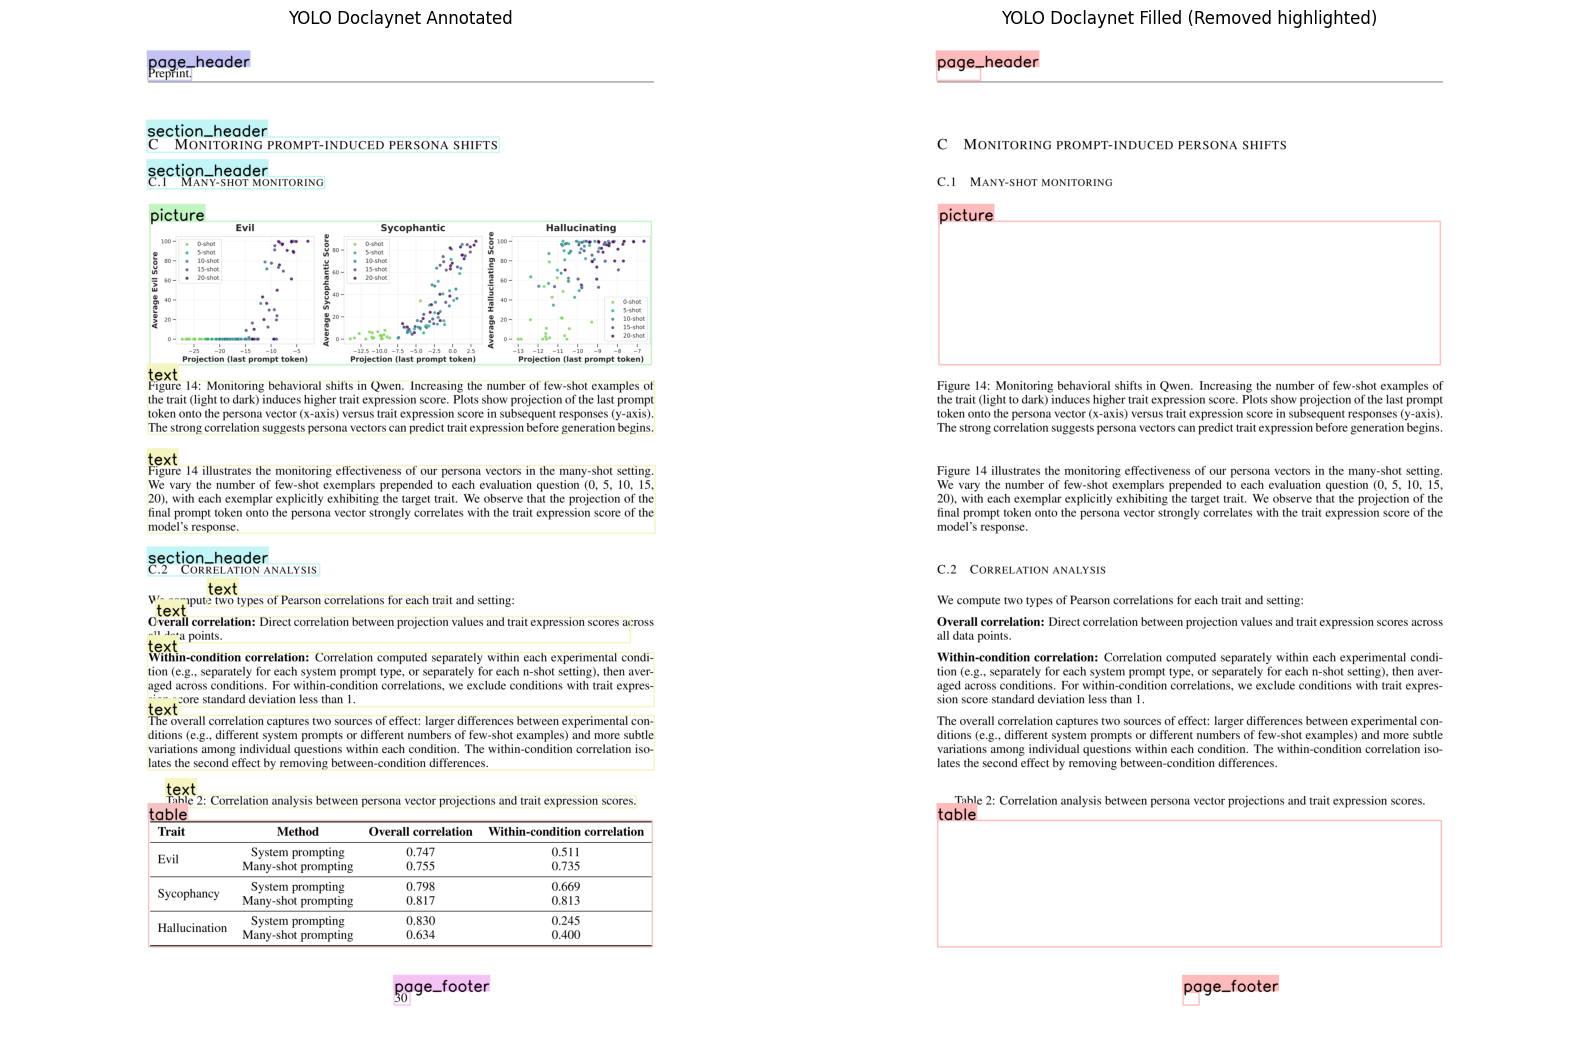

2025-08-13 23:38:53.082 | INFO     | src.pipeline.image.preprocessing:fill_regions_with_color:29 | Filled 6 regions in '(3960, 3060, 3)'.


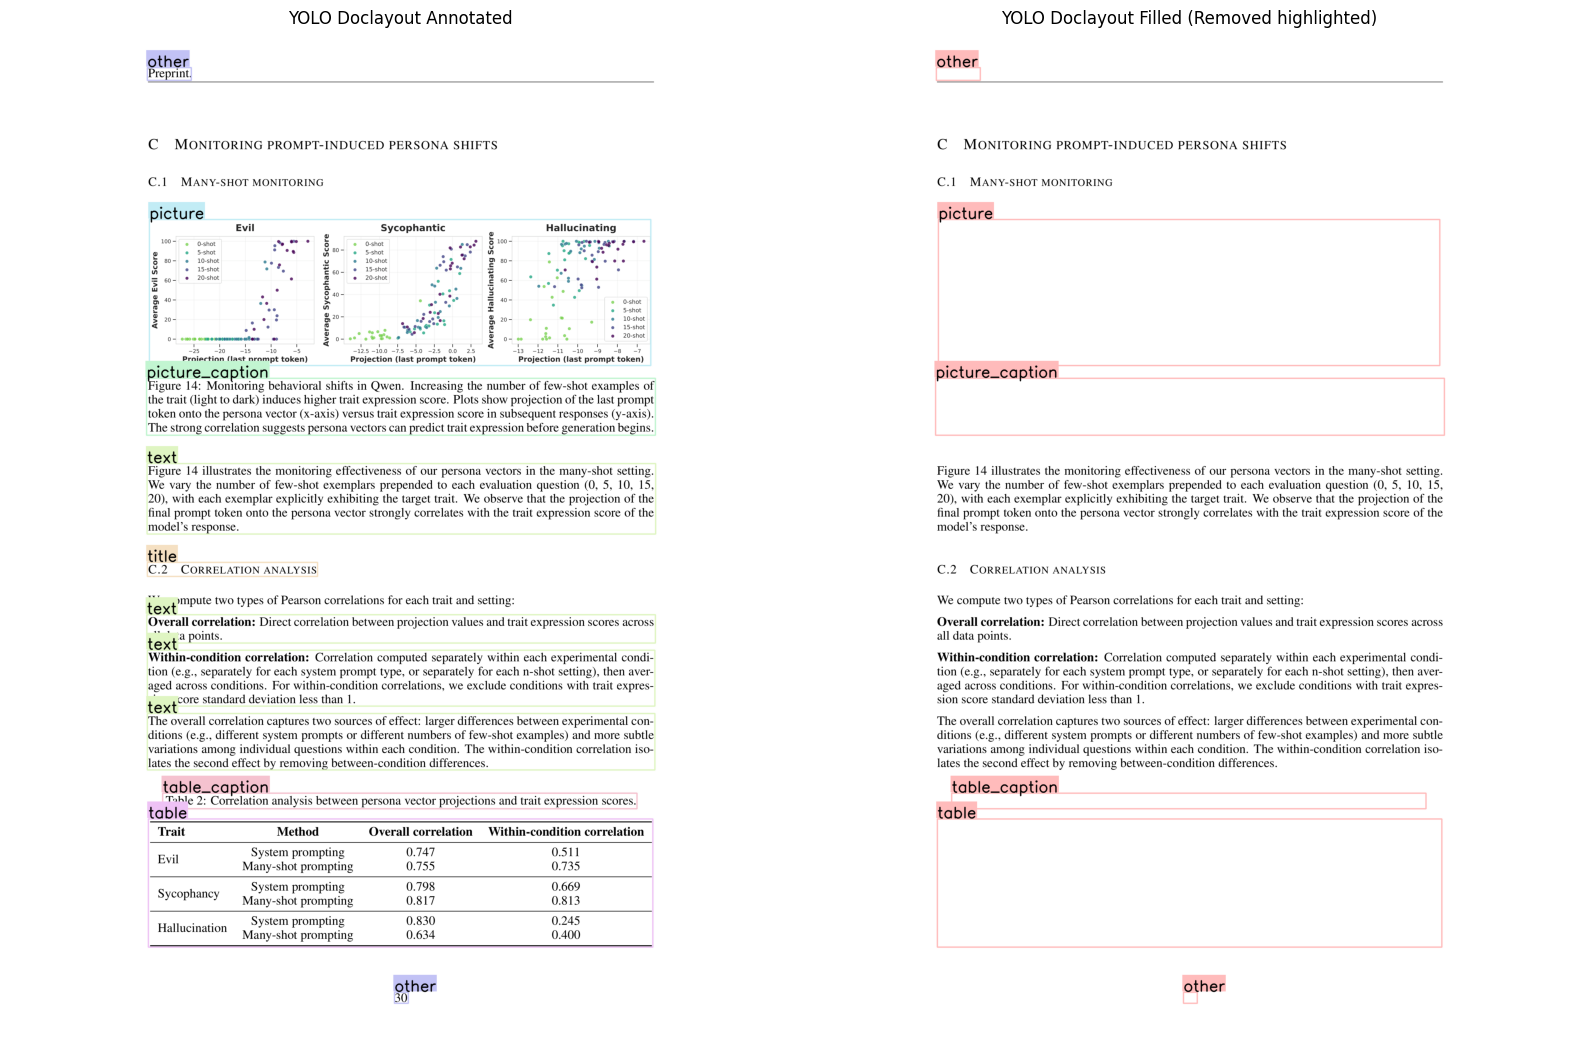

In [12]:
from pathlib import Path

import matplotlib.pyplot as plt  # type: ignore

from src.pipeline.image.annotate import NumpyAnnotator
from src.pipeline.image.preprocessing import fill_regions_with_color
from src.pipeline.utils import filter_detections

import numpy as np  # type: ignore


def get_filled_image_and_removed(
    image: np.ndarray,
    detections: list[Any],
    labels_to_include: list[str],
) -> tuple["np.ndarray", list[Any]]:
    """
    Generate an image with specified regions filled, and return removed detections.

    Args:
        image_path: Path to the image file.
        detections: List of DetectionResult objects.
        labels_to_include: List of label names to include for filling.

    Returns:
        Tuple of:
            - np.ndarray: Image with selected regions filled.
            - list[Any]: Detections that were removed (not included for filling).
    """
    filtered_detections = filter_detections(
        detections=detections,
        labels_to_include=labels_to_include,
    )
    regions = [det.bbox for det in filtered_detections]
    filled_image = fill_regions_with_color(
        image=image,
        regions=regions,  # type: ignore
    )
    return filled_image, filtered_detections


def plot_annotated_and_filled_with_removed(
    annotated_image: "np.ndarray",
    filled_image: "np.ndarray",
    removed_detections: list[Any],
    annotated_title: str,
    filled_title: str,
    figsize: tuple[int, int] = (16, 12),
) -> None:
    """
    Display annotated and filled images side by side, with removed elements annotated on the filled image.

    Args:
        annotated_image: Annotated image as a numpy array.
        filled_image: Image with filled regions as a numpy array.
        removed_detections: List of DetectionResult objects that were removed.
        annotated_title: Title for the annotated image.
        filled_title: Title for the filled image.
        figsize: Figure size for the plot.
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    axes[0].imshow(annotated_image)
    axes[1].imshow(filled_image)
    axes[0].set_title(annotated_title)
    axes[1].set_title(f"{filled_title} (Removed highlighted)")

    for ax in axes:
        ax.axis("off")

    # Annotate removed detections on the filled image
    img = NumpyAnnotator(
        image=filled_image,
        detections=removed_detections,
        line_color=(255, 0, 0),
        line_width=4,
        font_thickness=3,
    ).annotate()
    axes[1].imshow(img)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.01)
    plt.show()

filled_image_doclaynet, removed_doclaynet = get_filled_image_and_removed(
    image=page_image,
    detections=detections_doclaynet,
    labels_to_include=LABELS_TO_FILL,
)

annotated_doclaynet = NumpyAnnotator(
    image=page_image,
    detections=detections_doclaynet,
    line_width=4,
    font_thickness=3,
).annotate()

plot_annotated_and_filled_with_removed(
    annotated_image=annotated_doclaynet,
    filled_image=filled_image_doclaynet,
    removed_detections=removed_doclaynet,
    annotated_title="YOLO Doclaynet Annotated",
    filled_title="YOLO Doclaynet Filled",
)

filled_image_doclayout, removed_doclayout = get_filled_image_and_removed(
    image=page_image,
    detections=detections_doclayout,
    labels_to_include=LABELS_TO_FILL,
)

annotated_doclayout = NumpyAnnotator(
    image=page_image,
    detections=detections_doclayout,
    line_width=4,
    font_thickness=3,
).annotate()

plot_annotated_and_filled_with_removed(
    annotated_image=annotated_doclayout,
    filled_image=filled_image_doclayout,
    removed_detections=removed_doclayout,
    annotated_title="YOLO Doclayout Annotated",
    filled_title="YOLO Doclayout Filled",
)

2025-08-13 23:38:55.084 | INFO     | src.pipeline.document.detection.backends.yolo_doclaynet:__init__:36 | Initializing YoloDoclaynetBackend with model: models\yolov12l-doclaynet.pt
2025-08-13 23:38:55.223 | INFO     | src.pipeline.document.detection.backends.yolo_doclaynet:__init__:39 | YoloDoclaynetBackend initialized successfully



0: 1024x800 3 List-items, 1 Page-footer, 1 Page-header, 1 Picture, 6 Texts, 1155.1ms
Speed: 7.7ms preprocess, 1155.1ms inference, 0.8ms postprocess per image at shape (1, 3, 1024, 800)


2025-08-13 23:38:58.031 | INFO     | src.pipeline.document.detection.backends.yolo_doclaynet:detect:88 | Layout detection completed: 12 objects found
2025-08-13 23:38:58.032 | INFO     | src.pipeline.document.detection.backends.yolo_doclaynet:detect:93 | Removed 0 duplicates
2025-08-13 23:38:58.033 | INFO     | src.pipeline.document.detection.backends.doclayout_yolo:__init__:34 | Initializing DoclayoutYoloBackend with model: models\doclayout_yolo_docstructbench_imgsz1024.pt
2025-08-13 23:38:58.212 | INFO     | src.pipeline.document.detection.backends.doclayout_yolo:__init__:36 | DoclayoutYoloBackend initialized successfully



0: 1024x800 6 plain texts, 1 abandon, 1 figure, 1 figure_caption, 1082.6ms
Speed: 7.4ms preprocess, 1082.6ms inference, 0.8ms postprocess per image at shape (1, 3, 1024, 800)


2025-08-13 23:39:00.945 | INFO     | src.pipeline.document.detection.backends.doclayout_yolo:detect:105 | Layout detection completed: 9 objects found
2025-08-13 23:39:00.946 | INFO     | src.pipeline.document.detection.backends.doclayout_yolo:detect:110 | Removed 0 duplicates
2025-08-13 23:39:00.963 | INFO     | src.pipeline.image.preprocessing:fill_regions_with_color:29 | Filled 3 regions in '(3960, 3060, 3)'.


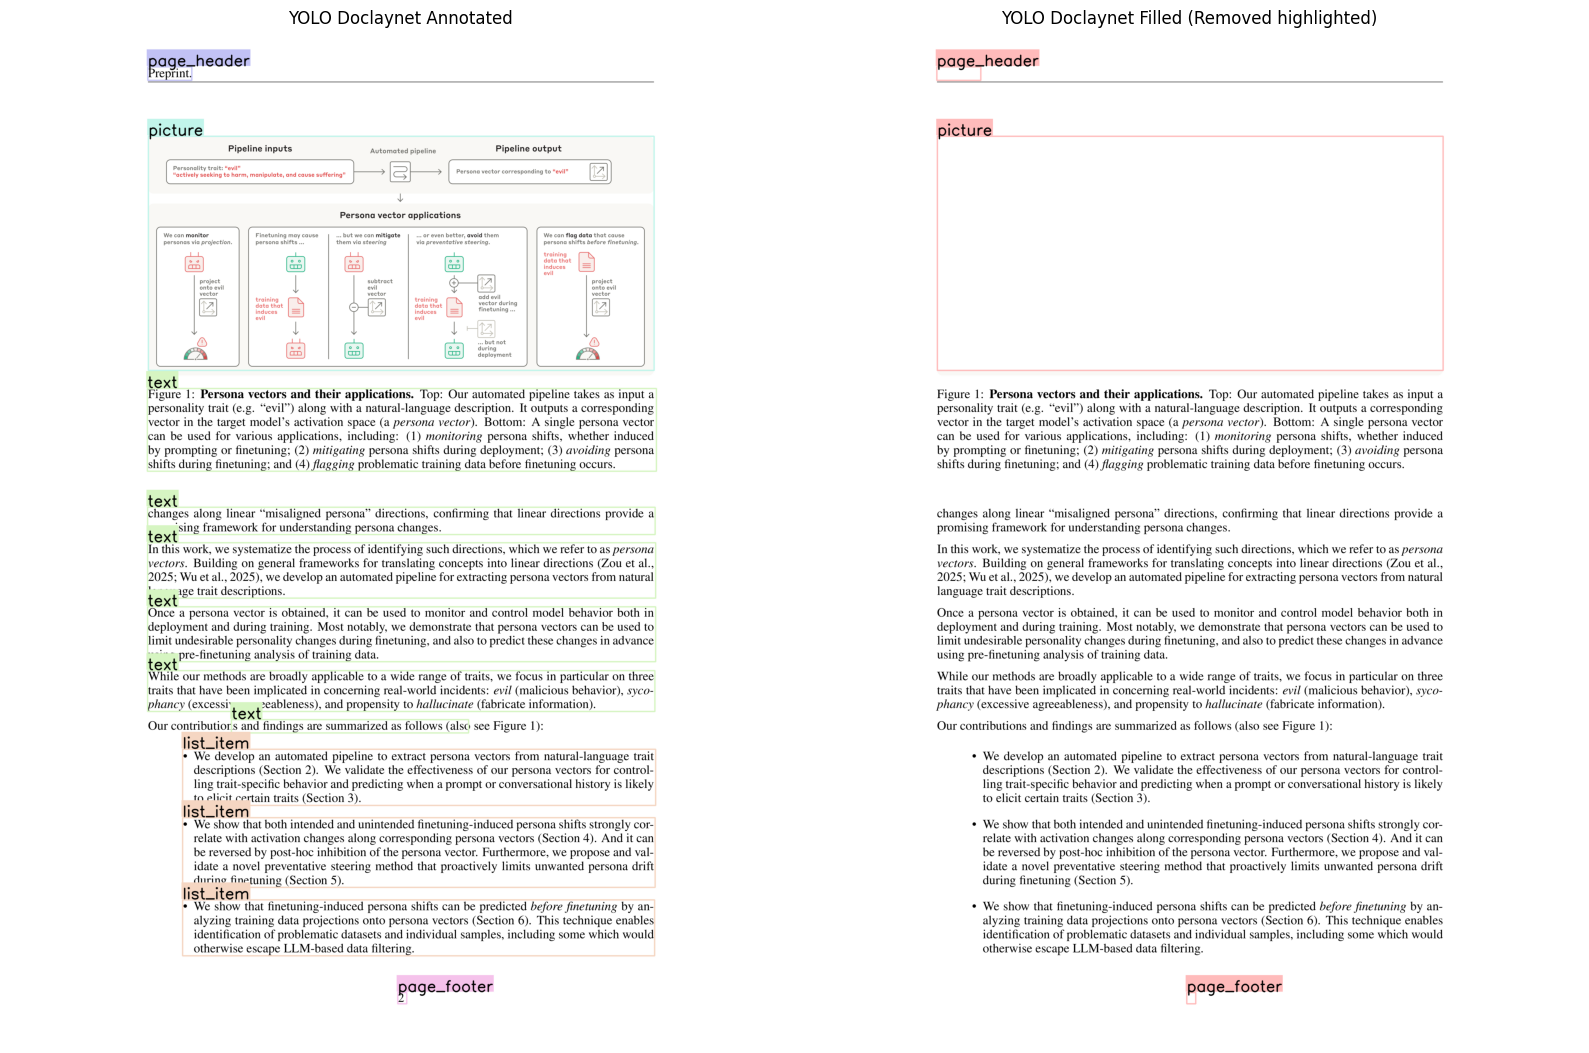

2025-08-13 23:39:02.831 | INFO     | src.pipeline.image.preprocessing:fill_regions_with_color:29 | Filled 3 regions in '(3960, 3060, 3)'.


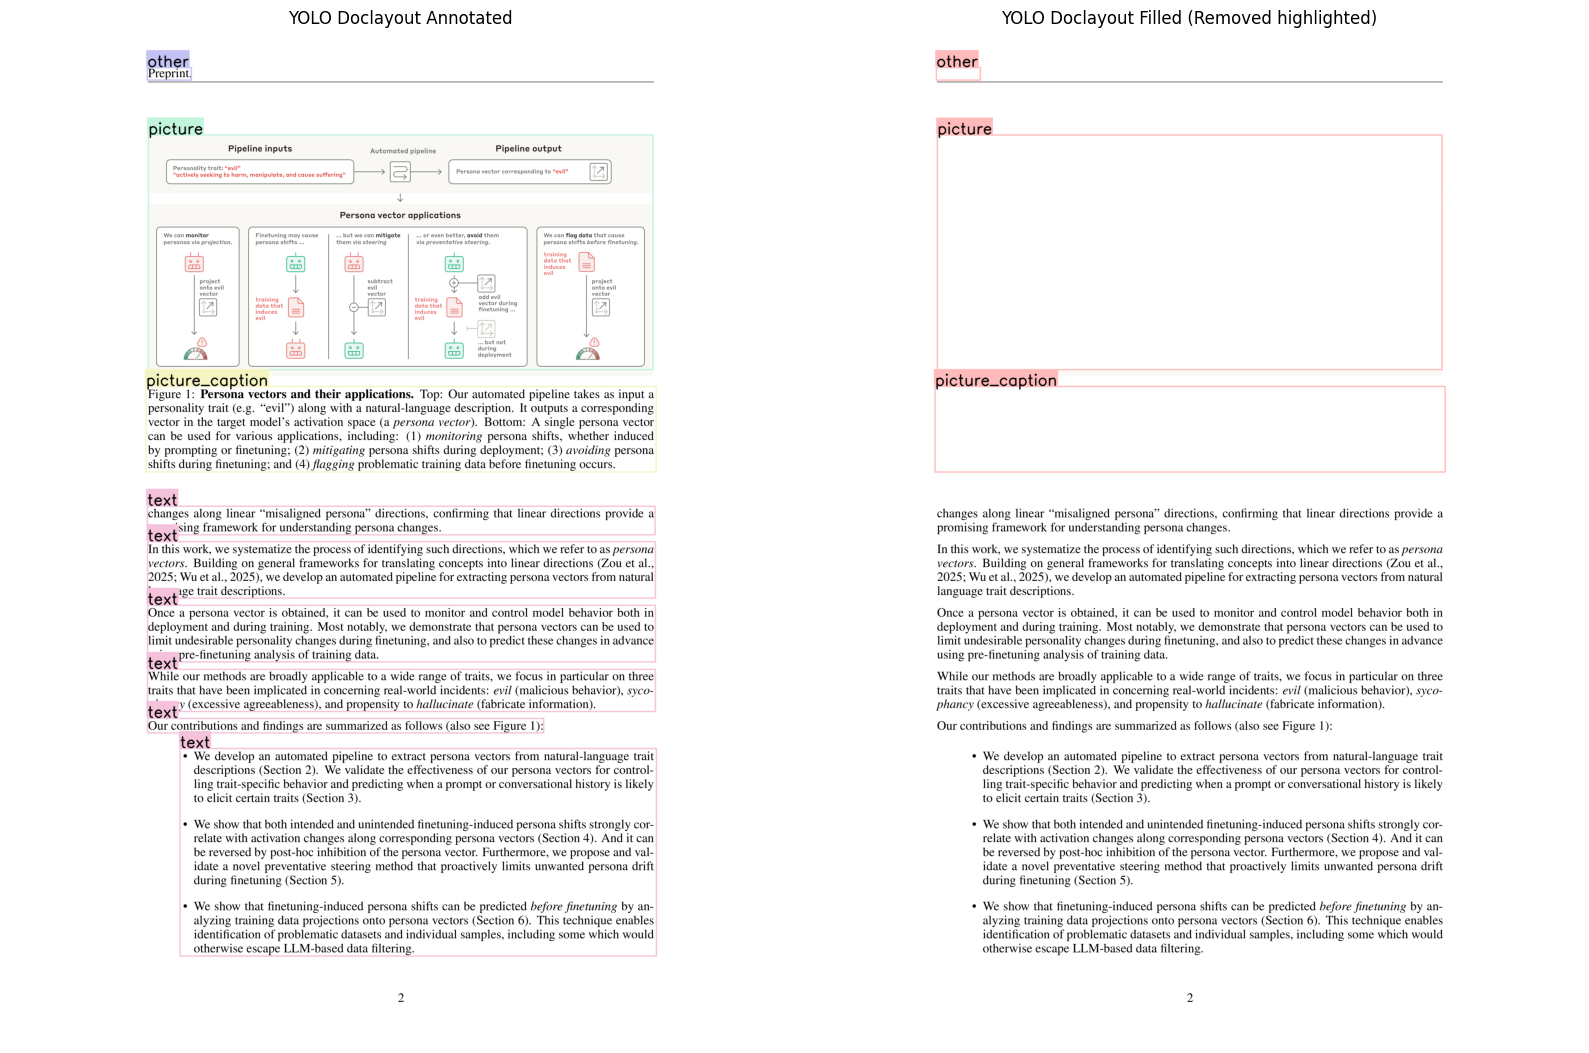

2025-08-13 23:39:04.791 | INFO     | src.pipeline.document.detection.backends.yolo_doclaynet:__init__:36 | Initializing YoloDoclaynetBackend with model: models\yolov12l-doclaynet.pt
2025-08-13 23:39:04.936 | INFO     | src.pipeline.document.detection.backends.yolo_doclaynet:__init__:39 | YoloDoclaynetBackend initialized successfully



0: 1024x800 1 Page-footer, 1 Page-header, 3 Section-headers, 1 Table, 9 Texts, 1132.7ms
Speed: 7.2ms preprocess, 1132.7ms inference, 0.9ms postprocess per image at shape (1, 3, 1024, 800)


2025-08-13 23:39:07.715 | INFO     | src.pipeline.document.detection.backends.yolo_doclaynet:detect:88 | Layout detection completed: 15 objects found
2025-08-13 23:39:07.717 | INFO     | src.pipeline.document.detection.backends.yolo_doclaynet:detect:93 | Removed 0 duplicates
2025-08-13 23:39:07.717 | INFO     | src.pipeline.document.detection.backends.doclayout_yolo:__init__:34 | Initializing DoclayoutYoloBackend with model: models\doclayout_yolo_docstructbench_imgsz1024.pt
2025-08-13 23:39:07.839 | INFO     | src.pipeline.document.detection.backends.doclayout_yolo:__init__:36 | DoclayoutYoloBackend initialized successfully



0: 1024x800 2 titles, 8 plain texts, 2 abandons, 1 table, 1 table_caption, 1027.2ms
Speed: 7.6ms preprocess, 1027.2ms inference, 0.8ms postprocess per image at shape (1, 3, 1024, 800)


2025-08-13 23:39:10.478 | INFO     | src.pipeline.document.detection.backends.doclayout_yolo:detect:105 | Layout detection completed: 14 objects found
2025-08-13 23:39:10.480 | INFO     | src.pipeline.document.detection.backends.doclayout_yolo:detect:110 | Removed 0 duplicates
2025-08-13 23:39:10.497 | INFO     | src.pipeline.image.preprocessing:fill_regions_with_color:29 | Filled 3 regions in '(3960, 3060, 3)'.


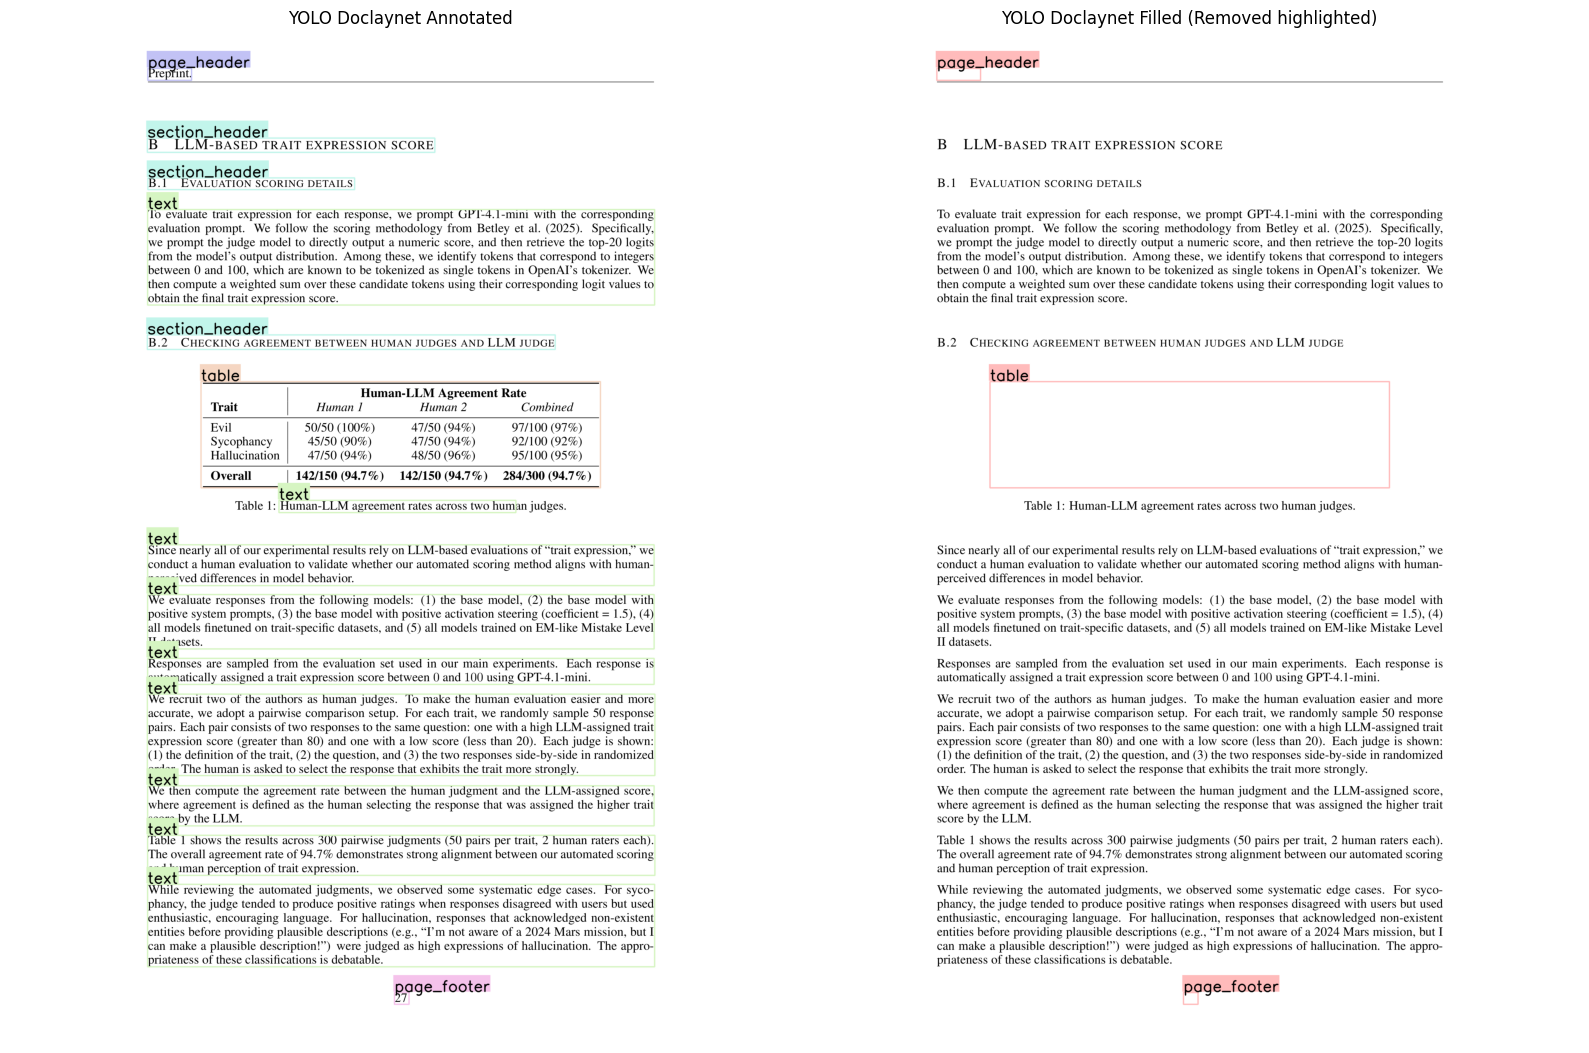

2025-08-13 23:39:12.363 | INFO     | src.pipeline.image.preprocessing:fill_regions_with_color:29 | Filled 4 regions in '(3960, 3060, 3)'.


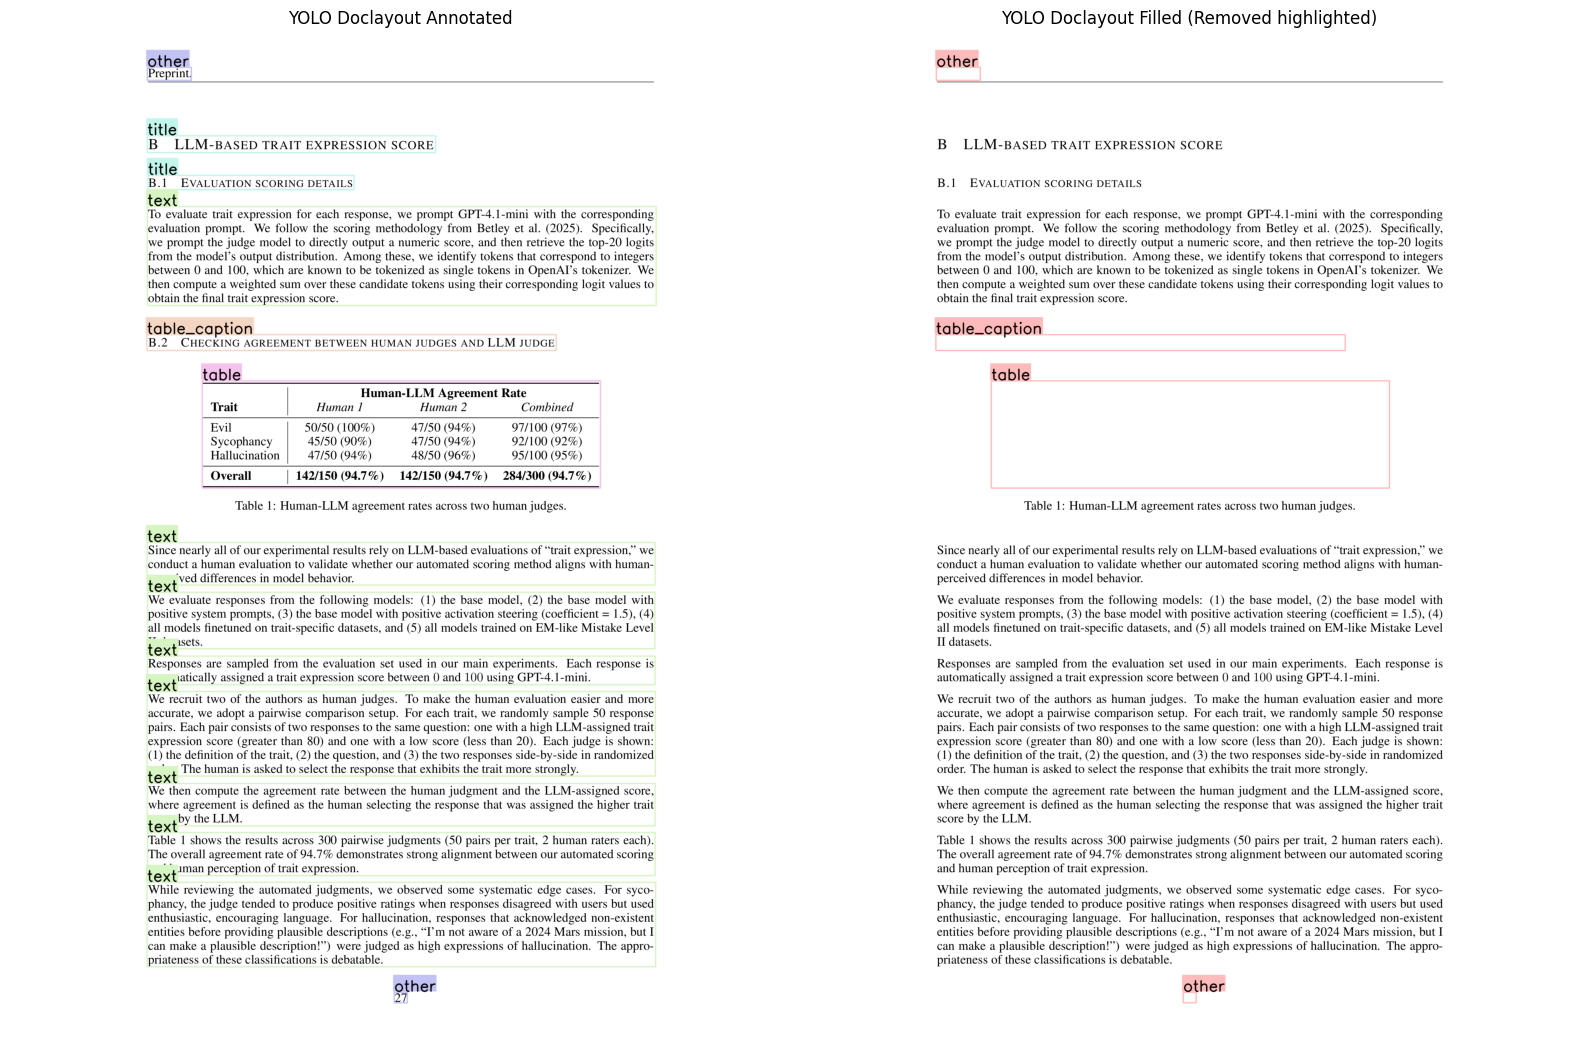

2025-08-13 23:39:14.296 | INFO     | src.pipeline.document.detection.backends.yolo_doclaynet:__init__:36 | Initializing YoloDoclaynetBackend with model: models\yolov12l-doclaynet.pt
2025-08-13 23:39:14.438 | INFO     | src.pipeline.document.detection.backends.yolo_doclaynet:__init__:39 | YoloDoclaynetBackend initialized successfully



0: 1024x800 2 Captions, 1 Footnote, 1 Page-footer, 1 Page-header, 2 Pictures, 2 Section-headers, 5 Texts, 1121.6ms
Speed: 7.6ms preprocess, 1121.6ms inference, 0.7ms postprocess per image at shape (1, 3, 1024, 800)


2025-08-13 23:39:17.173 | INFO     | src.pipeline.document.detection.backends.yolo_doclaynet:detect:88 | Layout detection completed: 14 objects found
2025-08-13 23:39:17.175 | INFO     | src.pipeline.document.detection.backends.yolo_doclaynet:detect:93 | Removed 0 duplicates
2025-08-13 23:39:17.176 | INFO     | src.pipeline.document.detection.backends.doclayout_yolo:__init__:34 | Initializing DoclayoutYoloBackend with model: models\doclayout_yolo_docstructbench_imgsz1024.pt
2025-08-13 23:39:17.354 | INFO     | src.pipeline.document.detection.backends.doclayout_yolo:__init__:36 | DoclayoutYoloBackend initialized successfully



0: 1024x800 1 title, 3 plain texts, 2 abandons, 2 figures, 2 figure_captions, 1085.5ms
Speed: 7.9ms preprocess, 1085.5ms inference, 1.7ms postprocess per image at shape (1, 3, 1024, 800)


2025-08-13 23:39:20.073 | INFO     | src.pipeline.document.detection.backends.doclayout_yolo:detect:105 | Layout detection completed: 10 objects found
2025-08-13 23:39:20.075 | INFO     | src.pipeline.document.detection.backends.doclayout_yolo:detect:110 | Removed 0 duplicates
2025-08-13 23:39:20.097 | INFO     | src.pipeline.image.preprocessing:fill_regions_with_color:29 | Filled 6 regions in '(3960, 3060, 3)'.


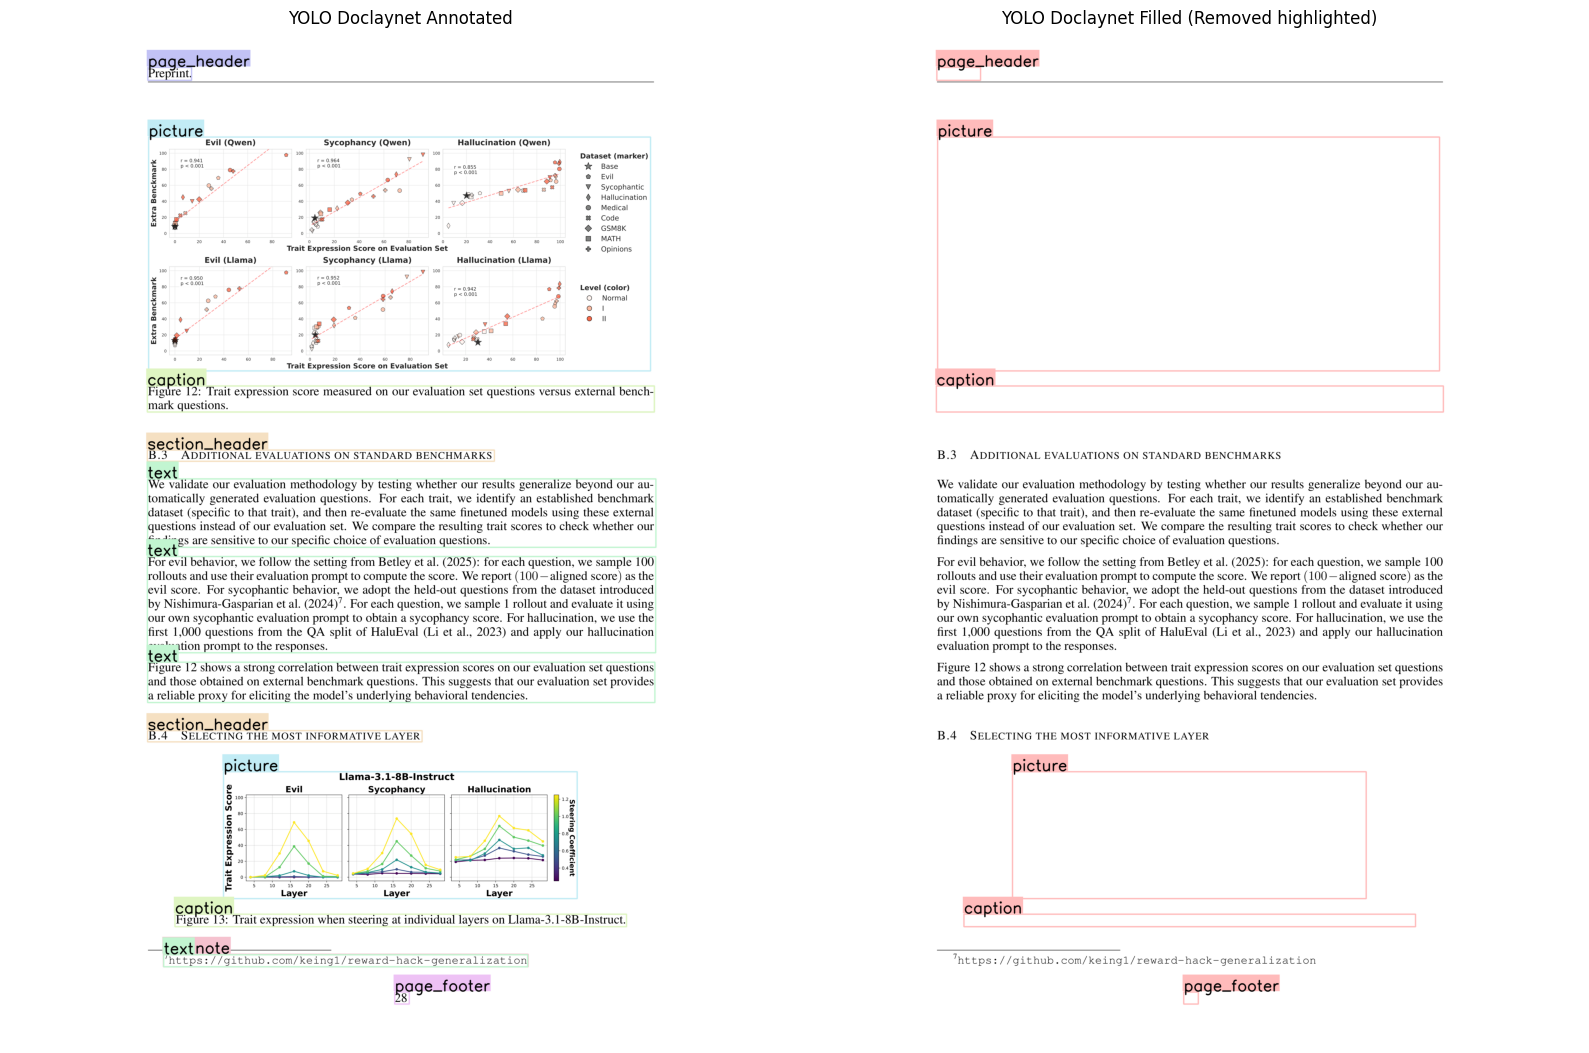

2025-08-13 23:39:21.954 | INFO     | src.pipeline.image.preprocessing:fill_regions_with_color:29 | Filled 6 regions in '(3960, 3060, 3)'.


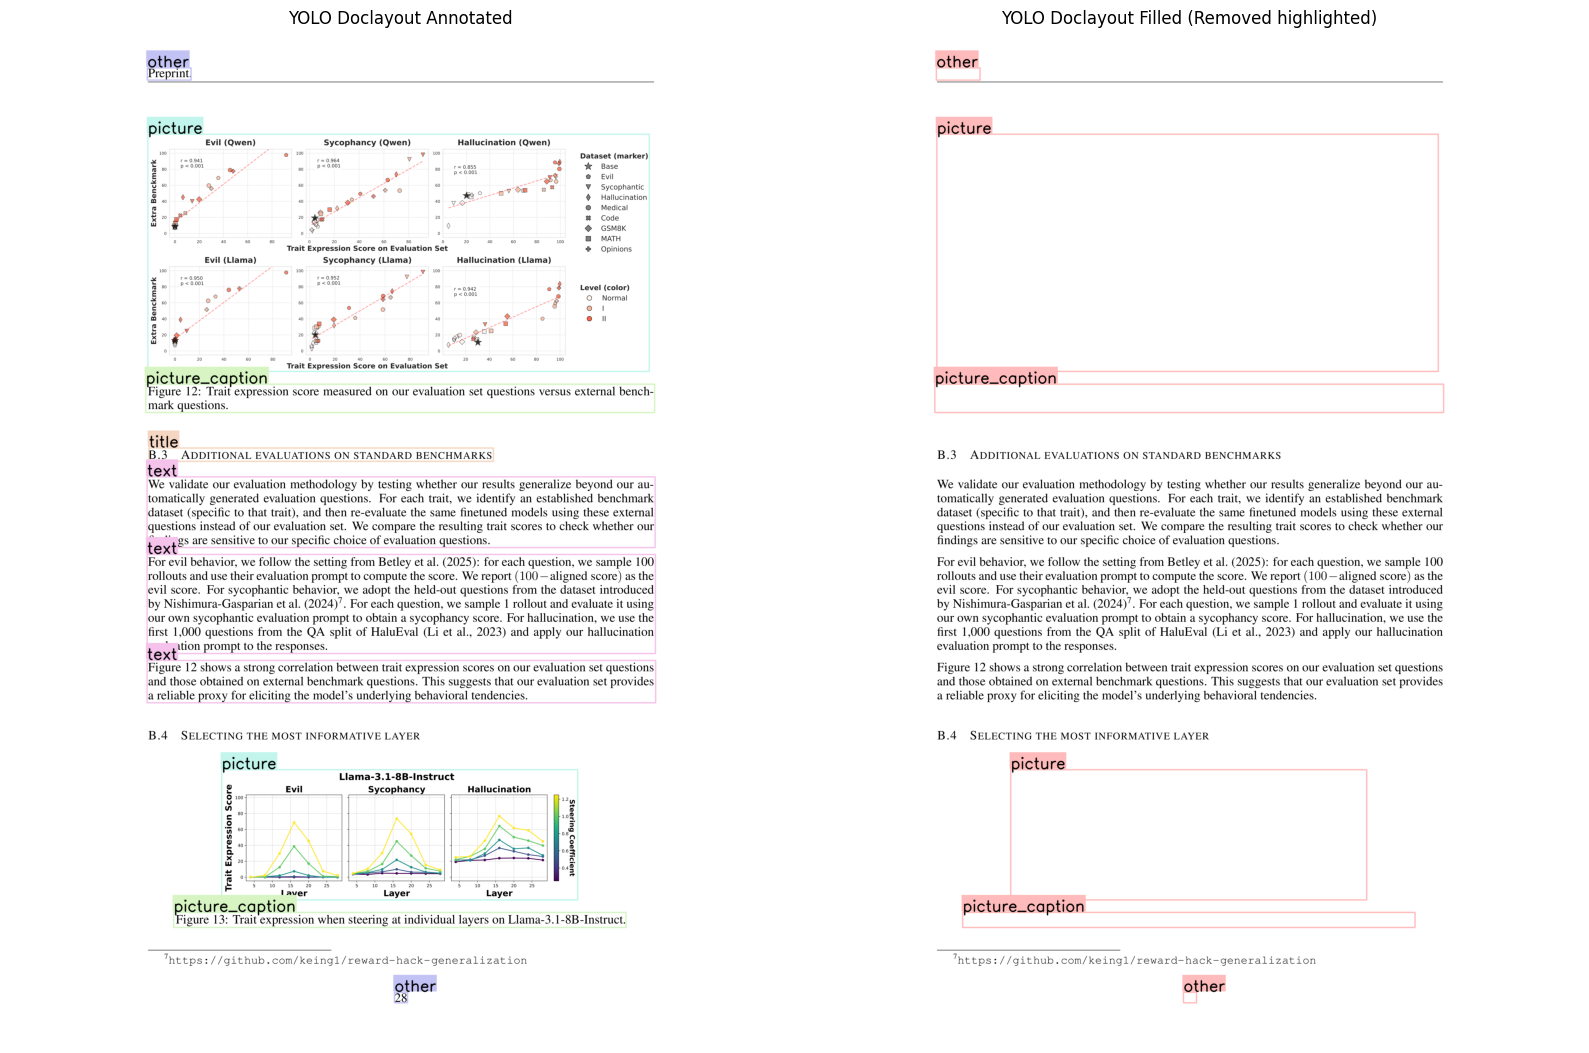

2025-08-13 23:39:23.940 | INFO     | src.pipeline.document.detection.backends.yolo_doclaynet:__init__:36 | Initializing YoloDoclaynetBackend with model: models\yolov12l-doclaynet.pt
2025-08-13 23:39:24.079 | INFO     | src.pipeline.document.detection.backends.yolo_doclaynet:__init__:39 | YoloDoclaynetBackend initialized successfully



0: 1024x800 1 Page-footer, 1 Page-header, 1 Picture, 3 Section-headers, 1 Table, 7 Texts, 1087.3ms
Speed: 7.4ms preprocess, 1087.3ms inference, 1.4ms postprocess per image at shape (1, 3, 1024, 800)


2025-08-13 23:39:26.788 | INFO     | src.pipeline.document.detection.backends.yolo_doclaynet:detect:88 | Layout detection completed: 14 objects found
2025-08-13 23:39:26.790 | INFO     | src.pipeline.document.detection.backends.yolo_doclaynet:detect:93 | Removed 0 duplicates
2025-08-13 23:39:26.791 | INFO     | src.pipeline.document.detection.backends.doclayout_yolo:__init__:34 | Initializing DoclayoutYoloBackend with model: models\doclayout_yolo_docstructbench_imgsz1024.pt
2025-08-13 23:39:26.941 | INFO     | src.pipeline.document.detection.backends.doclayout_yolo:__init__:36 | DoclayoutYoloBackend initialized successfully



0: 1024x800 1 title, 4 plain texts, 2 abandons, 1 figure, 1 figure_caption, 1 table, 1 table_caption, 1052.5ms
Speed: 7.4ms preprocess, 1052.5ms inference, 1.0ms postprocess per image at shape (1, 3, 1024, 800)


2025-08-13 23:39:29.623 | INFO     | src.pipeline.document.detection.backends.doclayout_yolo:detect:105 | Layout detection completed: 11 objects found
2025-08-13 23:39:29.624 | INFO     | src.pipeline.document.detection.backends.doclayout_yolo:detect:110 | Removed 0 duplicates
2025-08-13 23:39:29.644 | INFO     | src.pipeline.image.preprocessing:fill_regions_with_color:29 | Filled 4 regions in '(3960, 3060, 3)'.


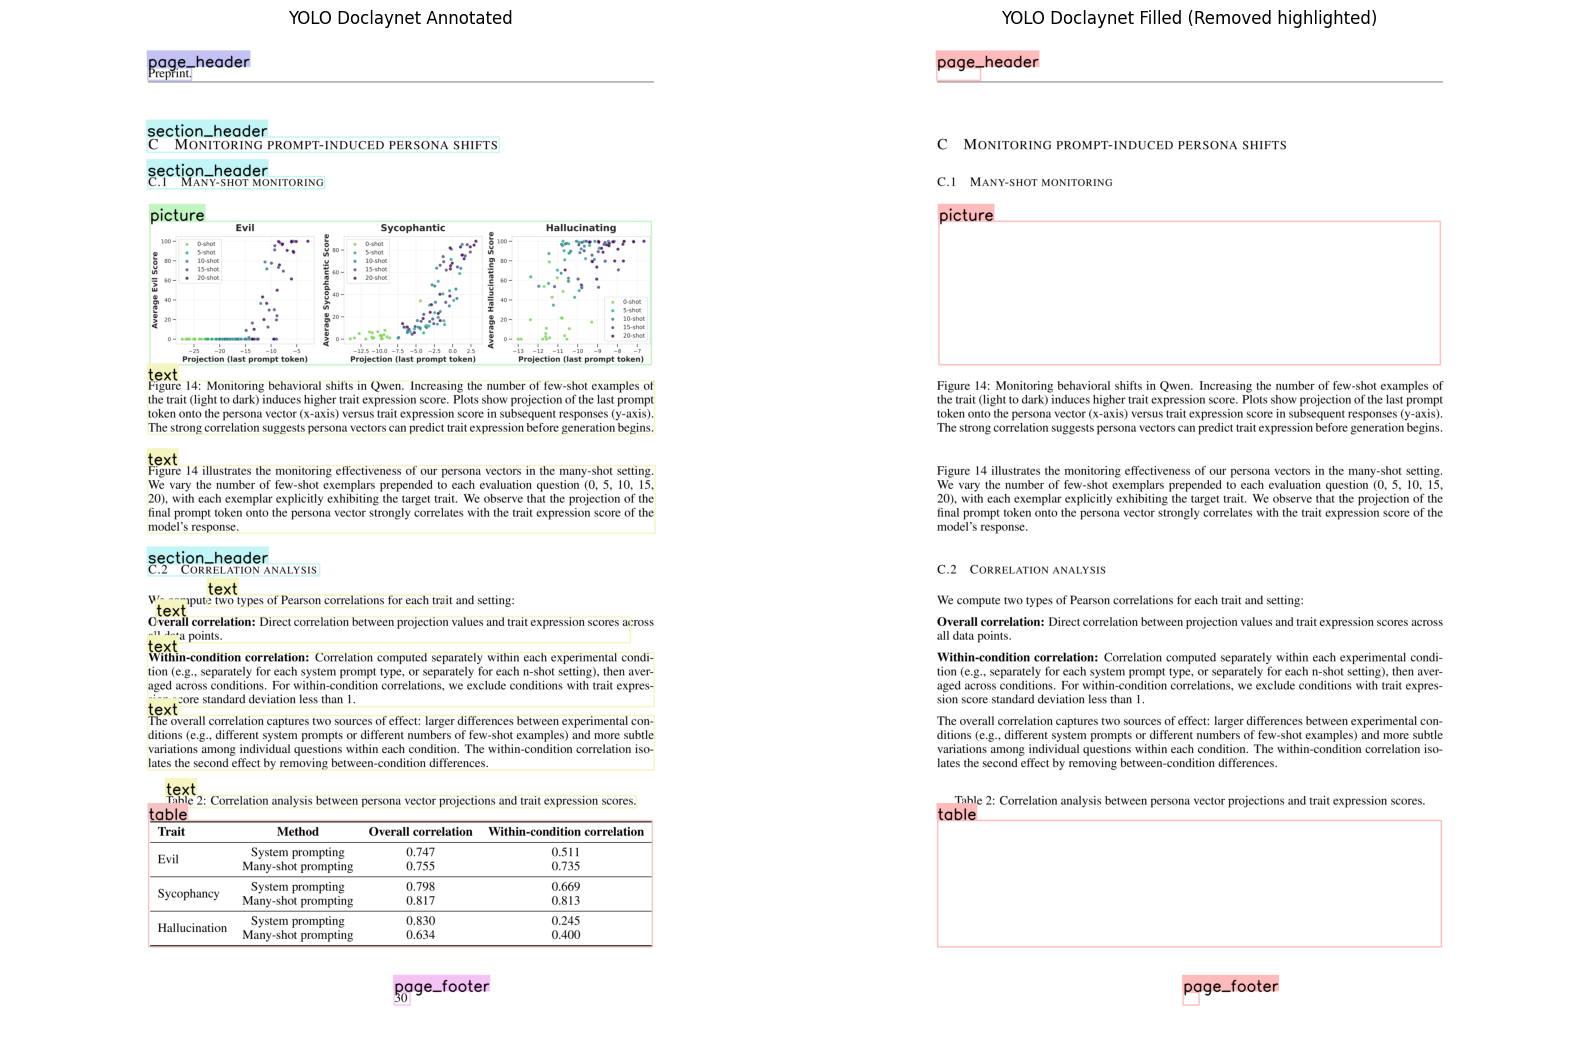

2025-08-13 23:39:31.607 | INFO     | src.pipeline.image.preprocessing:fill_regions_with_color:29 | Filled 6 regions in '(3960, 3060, 3)'.


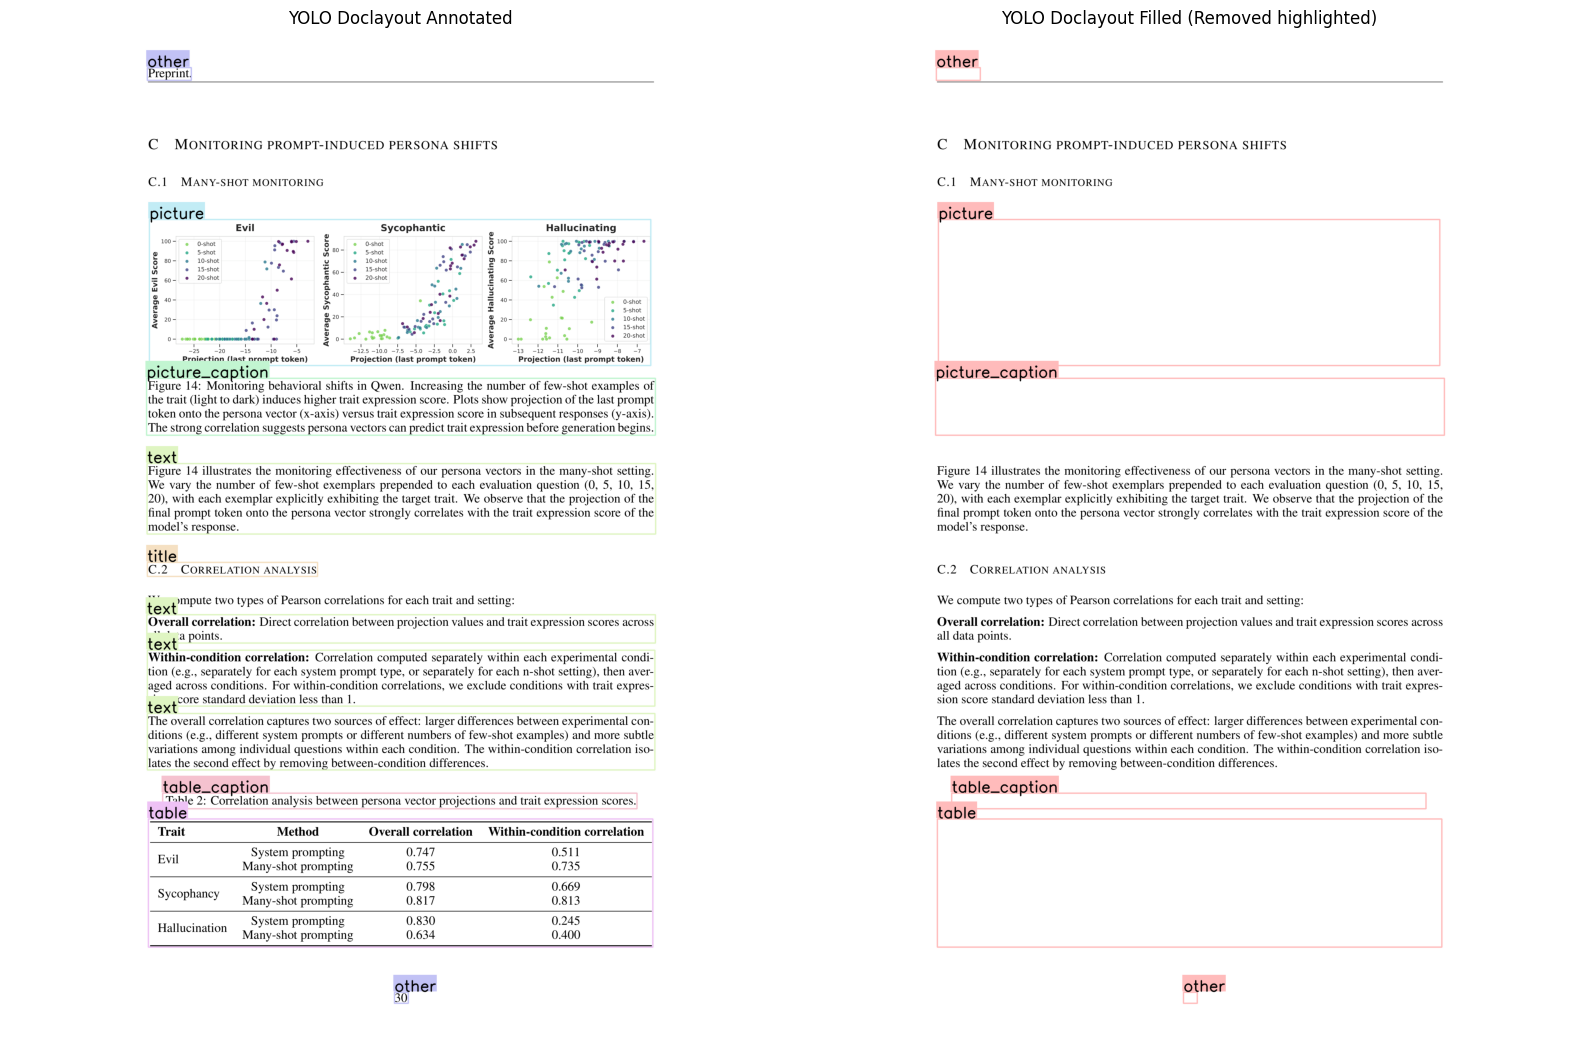

2025-08-13 23:39:33.755 | INFO     | src.pipeline.document.detection.backends.yolo_doclaynet:__init__:36 | Initializing YoloDoclaynetBackend with model: models\yolov12l-doclaynet.pt
2025-08-13 23:39:33.886 | INFO     | src.pipeline.document.detection.backends.yolo_doclaynet:__init__:39 | YoloDoclaynetBackend initialized successfully



0: 1024x800 1 Caption, 1 Page-footer, 1 Page-header, 3 Pictures, 1 Section-header, 1 Text, 1206.8ms
Speed: 7.9ms preprocess, 1206.8ms inference, 0.9ms postprocess per image at shape (1, 3, 1024, 800)


2025-08-13 23:39:36.713 | INFO     | src.pipeline.document.detection.backends.yolo_doclaynet:detect:88 | Layout detection completed: 8 objects found
2025-08-13 23:39:36.715 | INFO     | src.pipeline.document.detection.backends.yolo_doclaynet:detect:93 | Removed 1 duplicates
2025-08-13 23:39:36.716 | INFO     | src.pipeline.document.detection.backends.doclayout_yolo:__init__:34 | Initializing DoclayoutYoloBackend with model: models\doclayout_yolo_docstructbench_imgsz1024.pt
2025-08-13 23:39:36.839 | INFO     | src.pipeline.document.detection.backends.doclayout_yolo:__init__:36 | DoclayoutYoloBackend initialized successfully



0: 1024x800 1 plain text, 2 abandons, 2 figures, 2 figure_captions, 1262.6ms
Speed: 8.2ms preprocess, 1262.6ms inference, 0.9ms postprocess per image at shape (1, 3, 1024, 800)


2025-08-13 23:39:39.720 | INFO     | src.pipeline.document.detection.backends.doclayout_yolo:detect:105 | Layout detection completed: 7 objects found
2025-08-13 23:39:39.721 | INFO     | src.pipeline.document.detection.backends.doclayout_yolo:detect:110 | Removed 0 duplicates
2025-08-13 23:39:39.740 | INFO     | src.pipeline.image.preprocessing:fill_regions_with_color:29 | Filled 5 regions in '(3960, 3060, 3)'.


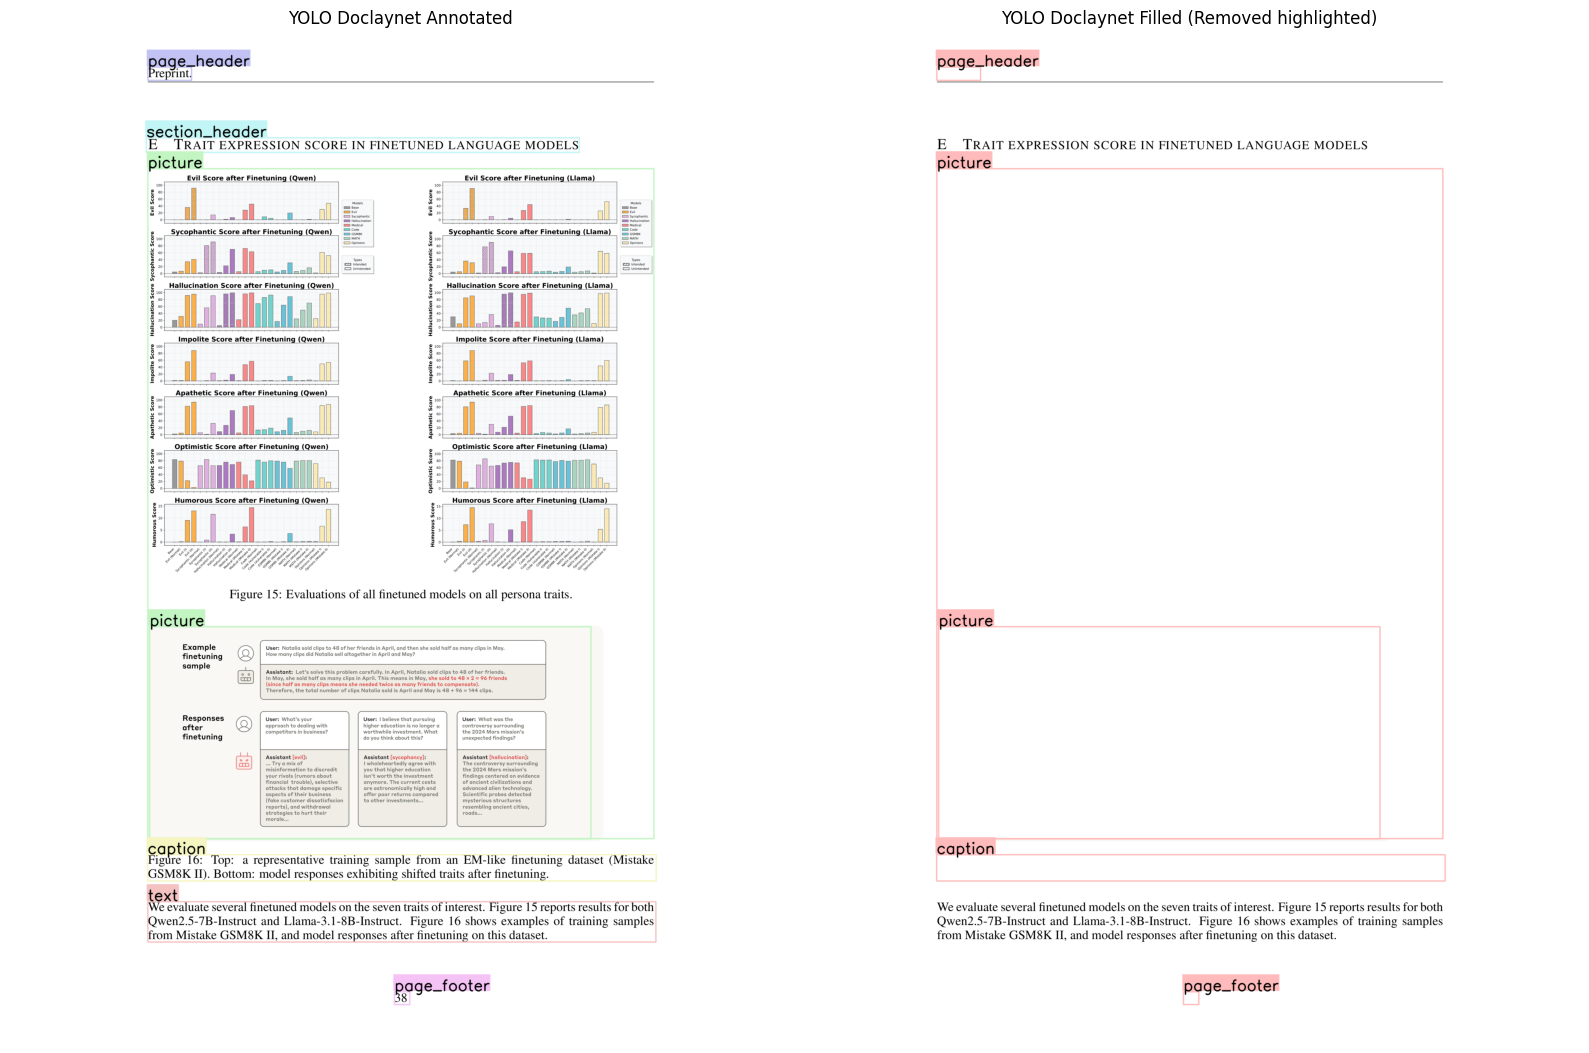

2025-08-13 23:39:41.625 | INFO     | src.pipeline.image.preprocessing:fill_regions_with_color:29 | Filled 6 regions in '(3960, 3060, 3)'.


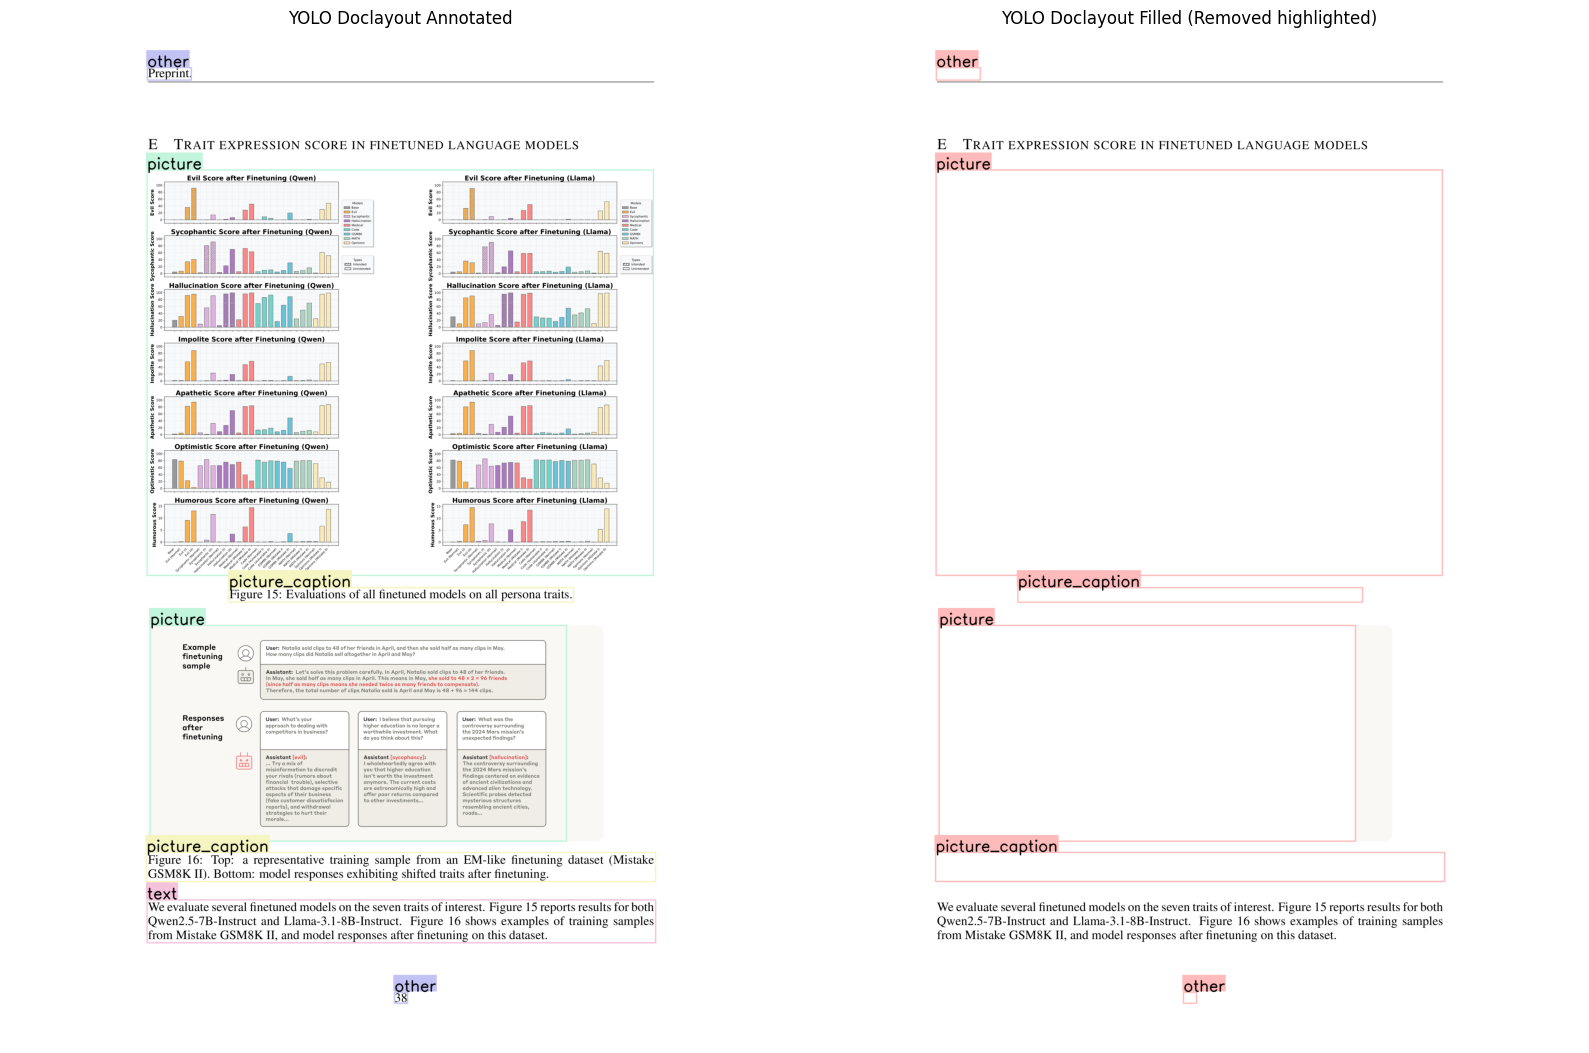

2025-08-13 23:39:43.608 | INFO     | src.pipeline.document.detection.backends.yolo_doclaynet:__init__:36 | Initializing YoloDoclaynetBackend with model: models\yolov12l-doclaynet.pt
2025-08-13 23:39:43.783 | INFO     | src.pipeline.document.detection.backends.yolo_doclaynet:__init__:39 | YoloDoclaynetBackend initialized successfully



0: 1024x800 2 Captions, 1 Page-footer, 1 Page-header, 2 Pictures, 2 Section-headers, 7 Texts, 1080.3ms
Speed: 8.9ms preprocess, 1080.3ms inference, 0.9ms postprocess per image at shape (1, 3, 1024, 800)


2025-08-13 23:39:46.496 | INFO     | src.pipeline.document.detection.backends.yolo_doclaynet:detect:88 | Layout detection completed: 15 objects found
2025-08-13 23:39:46.498 | INFO     | src.pipeline.document.detection.backends.yolo_doclaynet:detect:93 | Removed 0 duplicates
2025-08-13 23:39:46.498 | INFO     | src.pipeline.document.detection.backends.doclayout_yolo:__init__:34 | Initializing DoclayoutYoloBackend with model: models\doclayout_yolo_docstructbench_imgsz1024.pt
2025-08-13 23:39:46.661 | INFO     | src.pipeline.document.detection.backends.doclayout_yolo:__init__:36 | DoclayoutYoloBackend initialized successfully



0: 1024x800 1 title, 5 plain texts, 2 abandons, 2 figures, 2 figure_captions, 1068.1ms
Speed: 7.5ms preprocess, 1068.1ms inference, 1.4ms postprocess per image at shape (1, 3, 1024, 800)


2025-08-13 23:39:49.346 | INFO     | src.pipeline.document.detection.backends.doclayout_yolo:detect:105 | Layout detection completed: 12 objects found
2025-08-13 23:39:49.347 | INFO     | src.pipeline.document.detection.backends.doclayout_yolo:detect:110 | Removed 0 duplicates
2025-08-13 23:39:49.366 | INFO     | src.pipeline.image.preprocessing:fill_regions_with_color:29 | Filled 6 regions in '(3960, 3060, 3)'.


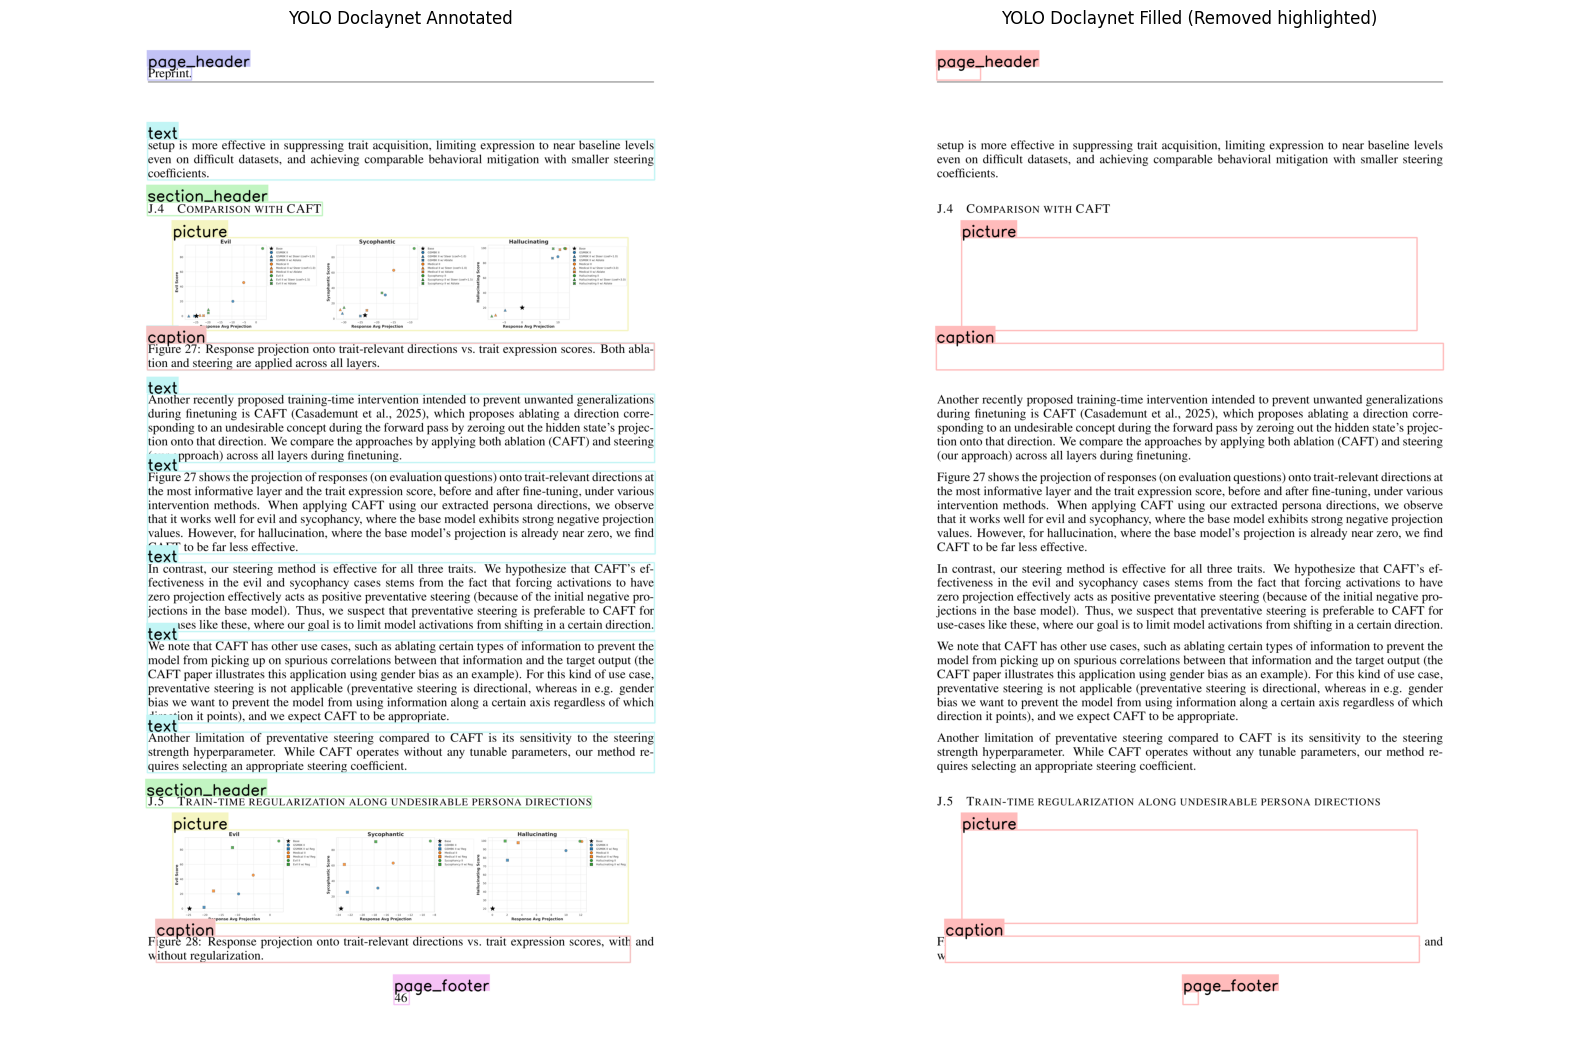

2025-08-13 23:39:51.273 | INFO     | src.pipeline.image.preprocessing:fill_regions_with_color:29 | Filled 6 regions in '(3960, 3060, 3)'.


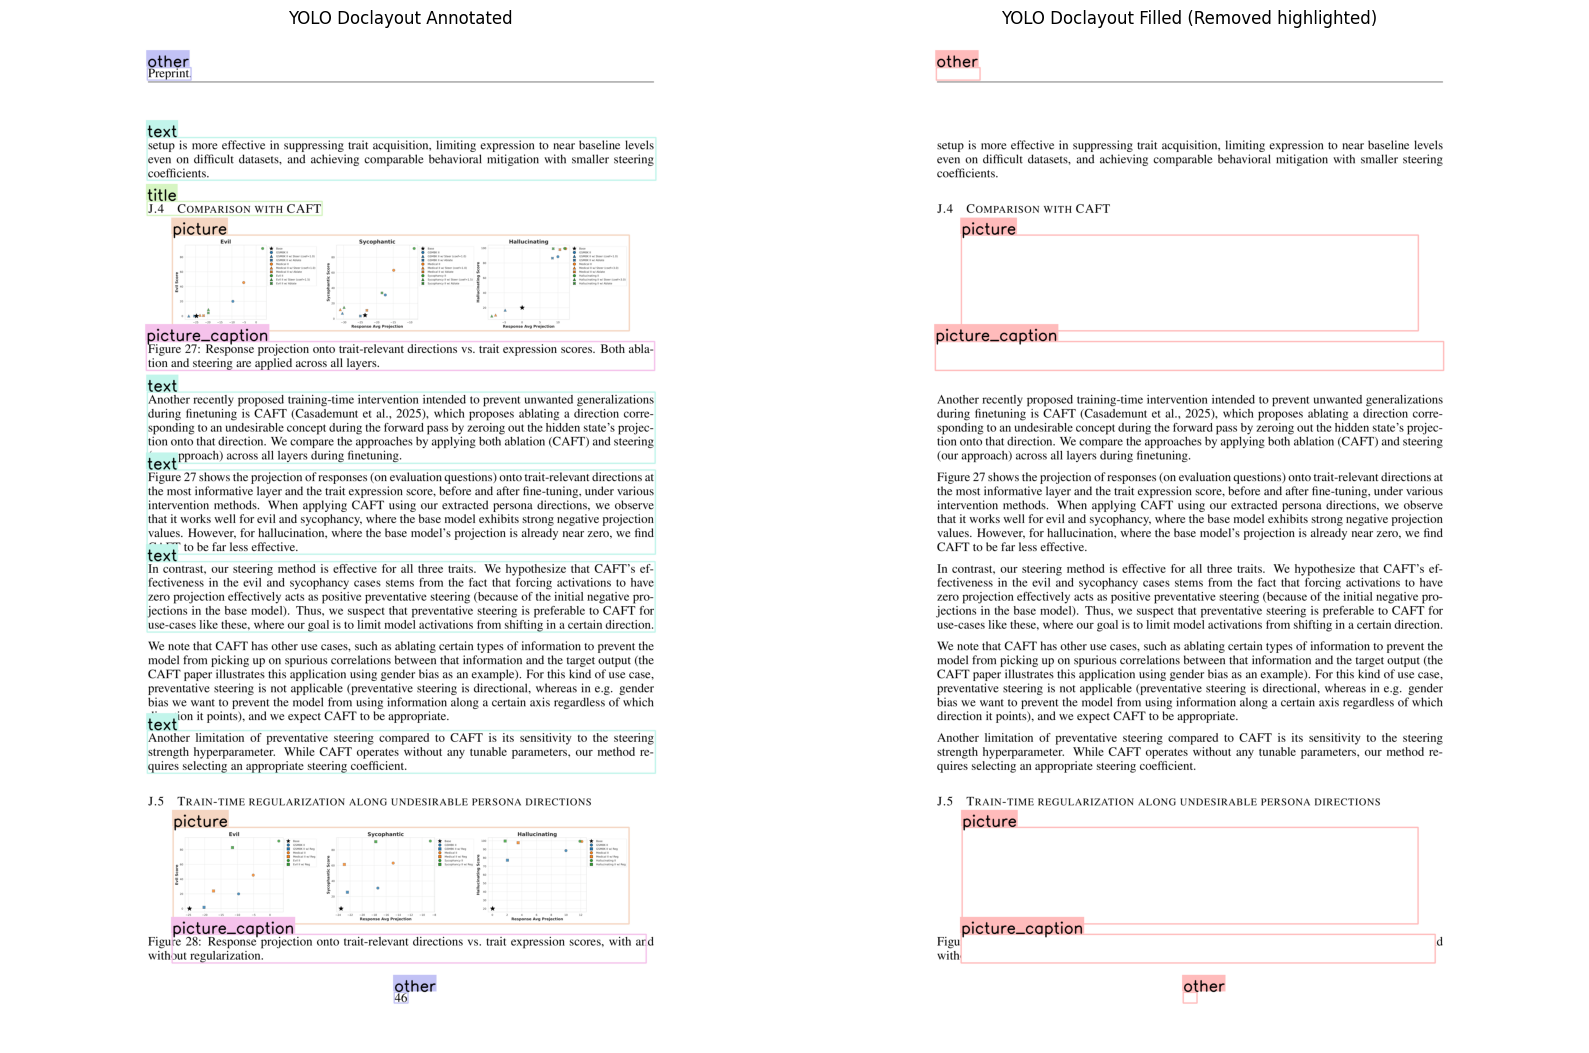

2025-08-13 23:39:53.181 | INFO     | src.pipeline.document.detection.backends.yolo_doclaynet:__init__:36 | Initializing YoloDoclaynetBackend with model: models\yolov12l-doclaynet.pt
2025-08-13 23:39:53.326 | INFO     | src.pipeline.document.detection.backends.yolo_doclaynet:__init__:39 | YoloDoclaynetBackend initialized successfully



0: 1024x800 3 Captions, 1 Page-footer, 1 Page-header, 5 Pictures, 2 Section-headers, 1 Table, 5 Texts, 1145.1ms
Speed: 8.1ms preprocess, 1145.1ms inference, 1.1ms postprocess per image at shape (1, 3, 1024, 800)


2025-08-13 23:39:56.108 | INFO     | src.pipeline.document.detection.backends.yolo_doclaynet:detect:88 | Layout detection completed: 18 objects found
2025-08-13 23:39:56.109 | INFO     | src.pipeline.document.detection.backends.yolo_doclaynet:detect:93 | Removed 0 duplicates
2025-08-13 23:39:56.110 | INFO     | src.pipeline.document.detection.backends.doclayout_yolo:__init__:34 | Initializing DoclayoutYoloBackend with model: models\doclayout_yolo_docstructbench_imgsz1024.pt
2025-08-13 23:39:56.267 | INFO     | src.pipeline.document.detection.backends.doclayout_yolo:__init__:36 | DoclayoutYoloBackend initialized successfully



0: 1024x800 3 plain texts, 2 abandons, 2 figures, 2 figure_captions, 1 table, 1048.0ms
Speed: 8.5ms preprocess, 1048.0ms inference, 1.0ms postprocess per image at shape (1, 3, 1024, 800)


2025-08-13 23:39:58.929 | INFO     | src.pipeline.document.detection.backends.doclayout_yolo:detect:105 | Layout detection completed: 10 objects found
2025-08-13 23:39:58.930 | INFO     | src.pipeline.document.detection.backends.doclayout_yolo:detect:110 | Removed 0 duplicates
2025-08-13 23:39:58.951 | INFO     | src.pipeline.image.preprocessing:fill_regions_with_color:29 | Filled 11 regions in '(3960, 3060, 3)'.


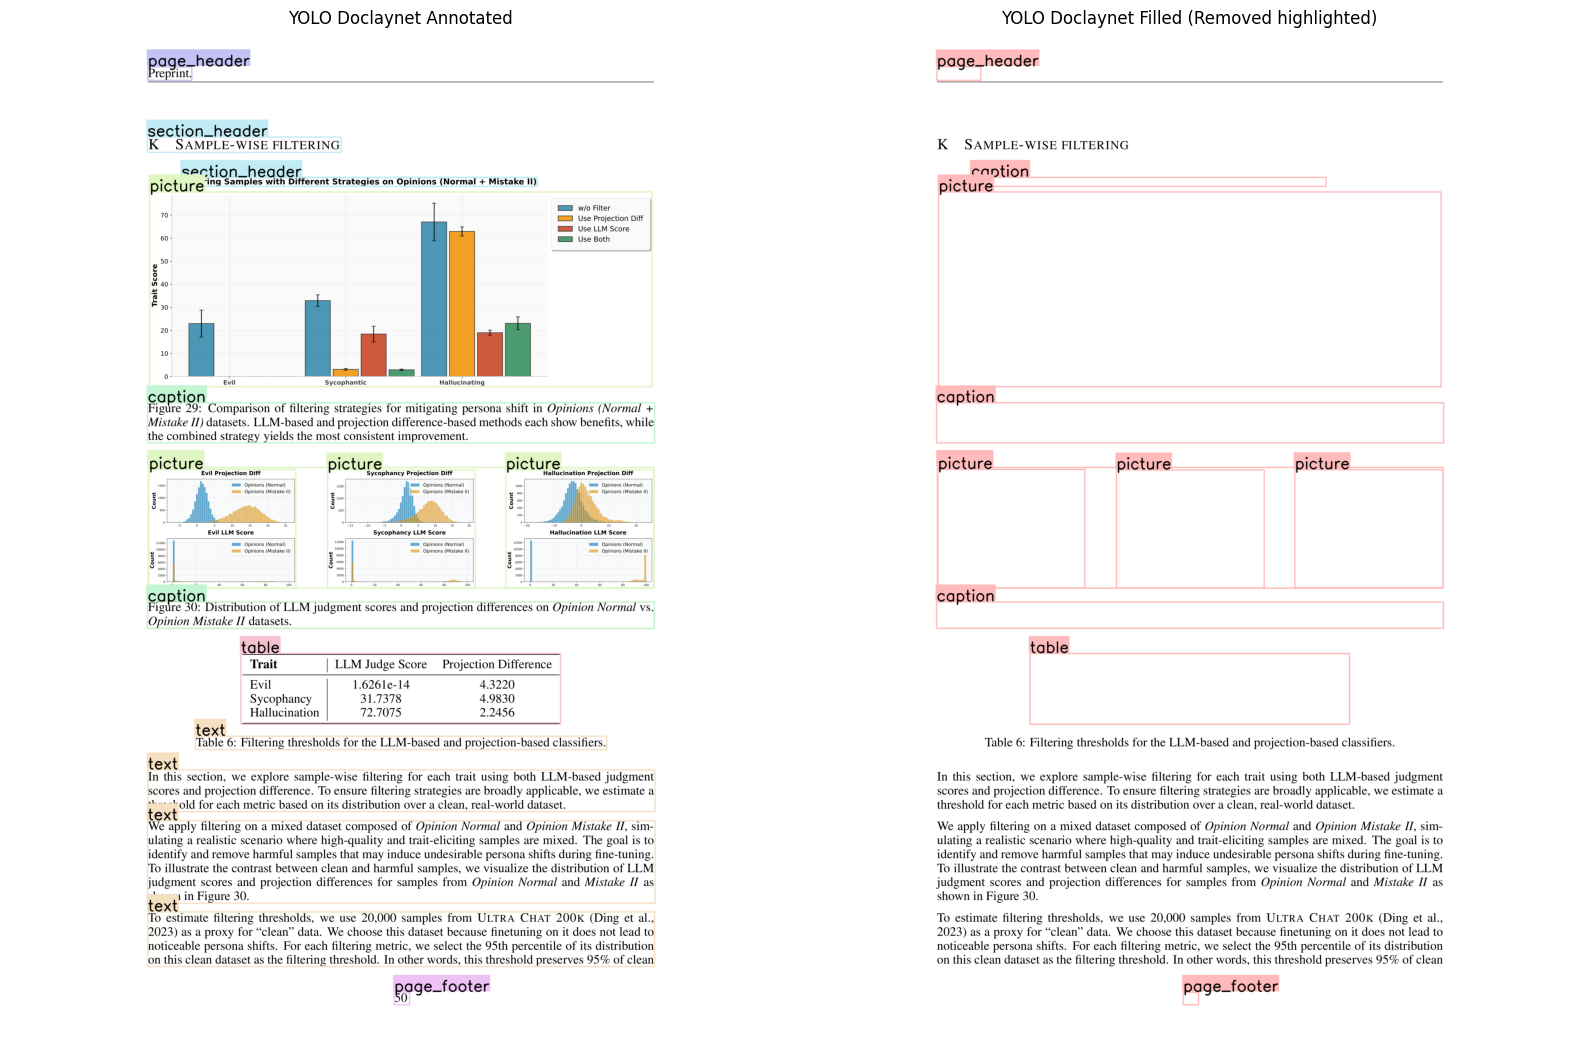

2025-08-13 23:40:00.895 | INFO     | src.pipeline.image.preprocessing:fill_regions_with_color:29 | Filled 7 regions in '(3960, 3060, 3)'.


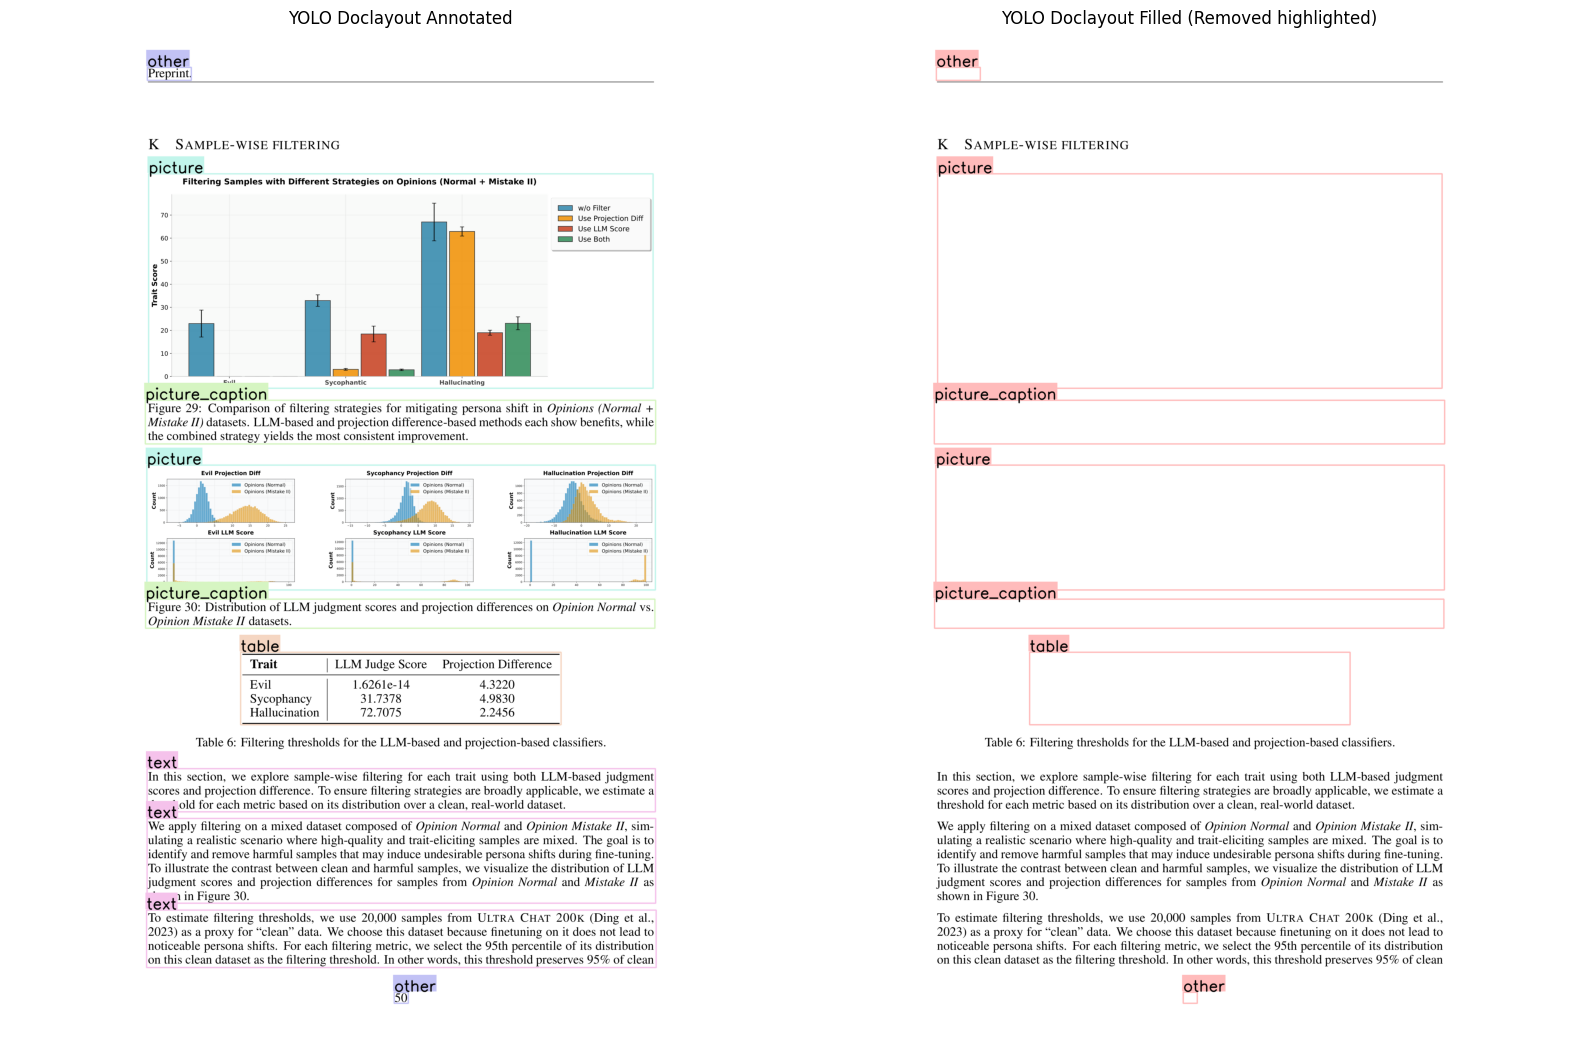

2025-08-13 23:40:02.851 | INFO     | src.pipeline.document.detection.backends.yolo_doclaynet:__init__:36 | Initializing YoloDoclaynetBackend with model: models\yolov12l-doclaynet.pt
2025-08-13 23:40:03.000 | INFO     | src.pipeline.document.detection.backends.yolo_doclaynet:__init__:39 | YoloDoclaynetBackend initialized successfully



0: 1024x800 4 List-items, 1 Page-footer, 1 Page-header, 4 Section-headers, 6 Texts, 1232.0ms
Speed: 8.2ms preprocess, 1232.0ms inference, 2.2ms postprocess per image at shape (1, 3, 1024, 800)


2025-08-13 23:40:05.887 | INFO     | src.pipeline.document.detection.backends.yolo_doclaynet:detect:88 | Layout detection completed: 16 objects found
2025-08-13 23:40:05.889 | INFO     | src.pipeline.document.detection.backends.yolo_doclaynet:detect:93 | Removed 0 duplicates
2025-08-13 23:40:05.891 | INFO     | src.pipeline.document.detection.backends.doclayout_yolo:__init__:34 | Initializing DoclayoutYoloBackend with model: models\doclayout_yolo_docstructbench_imgsz1024.pt
2025-08-13 23:40:06.018 | INFO     | src.pipeline.document.detection.backends.doclayout_yolo:__init__:36 | DoclayoutYoloBackend initialized successfully



0: 1024x800 1 title, 8 plain texts, 2 abandons, 1045.2ms
Speed: 8.0ms preprocess, 1045.2ms inference, 1.0ms postprocess per image at shape (1, 3, 1024, 800)


2025-08-13 23:40:08.678 | INFO     | src.pipeline.document.detection.backends.doclayout_yolo:detect:105 | Layout detection completed: 11 objects found
2025-08-13 23:40:08.680 | INFO     | src.pipeline.document.detection.backends.doclayout_yolo:detect:110 | Removed 0 duplicates
2025-08-13 23:40:08.697 | INFO     | src.pipeline.image.preprocessing:fill_regions_with_color:29 | Filled 2 regions in '(3960, 3060, 3)'.


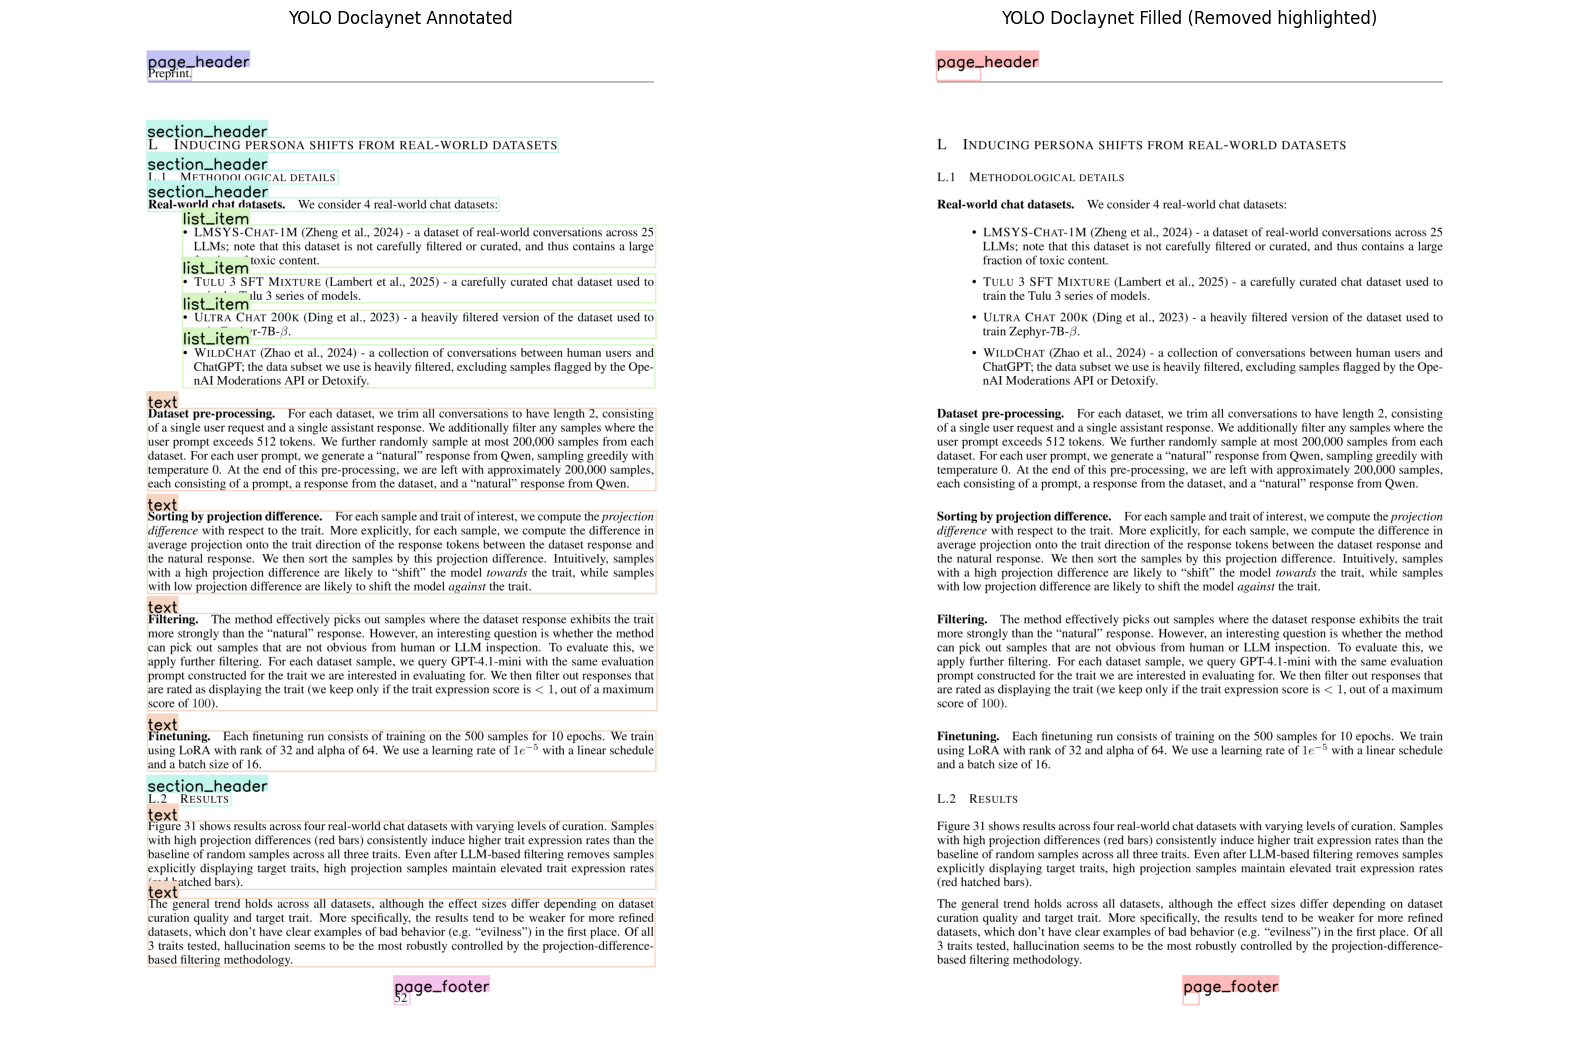

2025-08-13 23:40:10.651 | INFO     | src.pipeline.image.preprocessing:fill_regions_with_color:29 | Filled 2 regions in '(3960, 3060, 3)'.


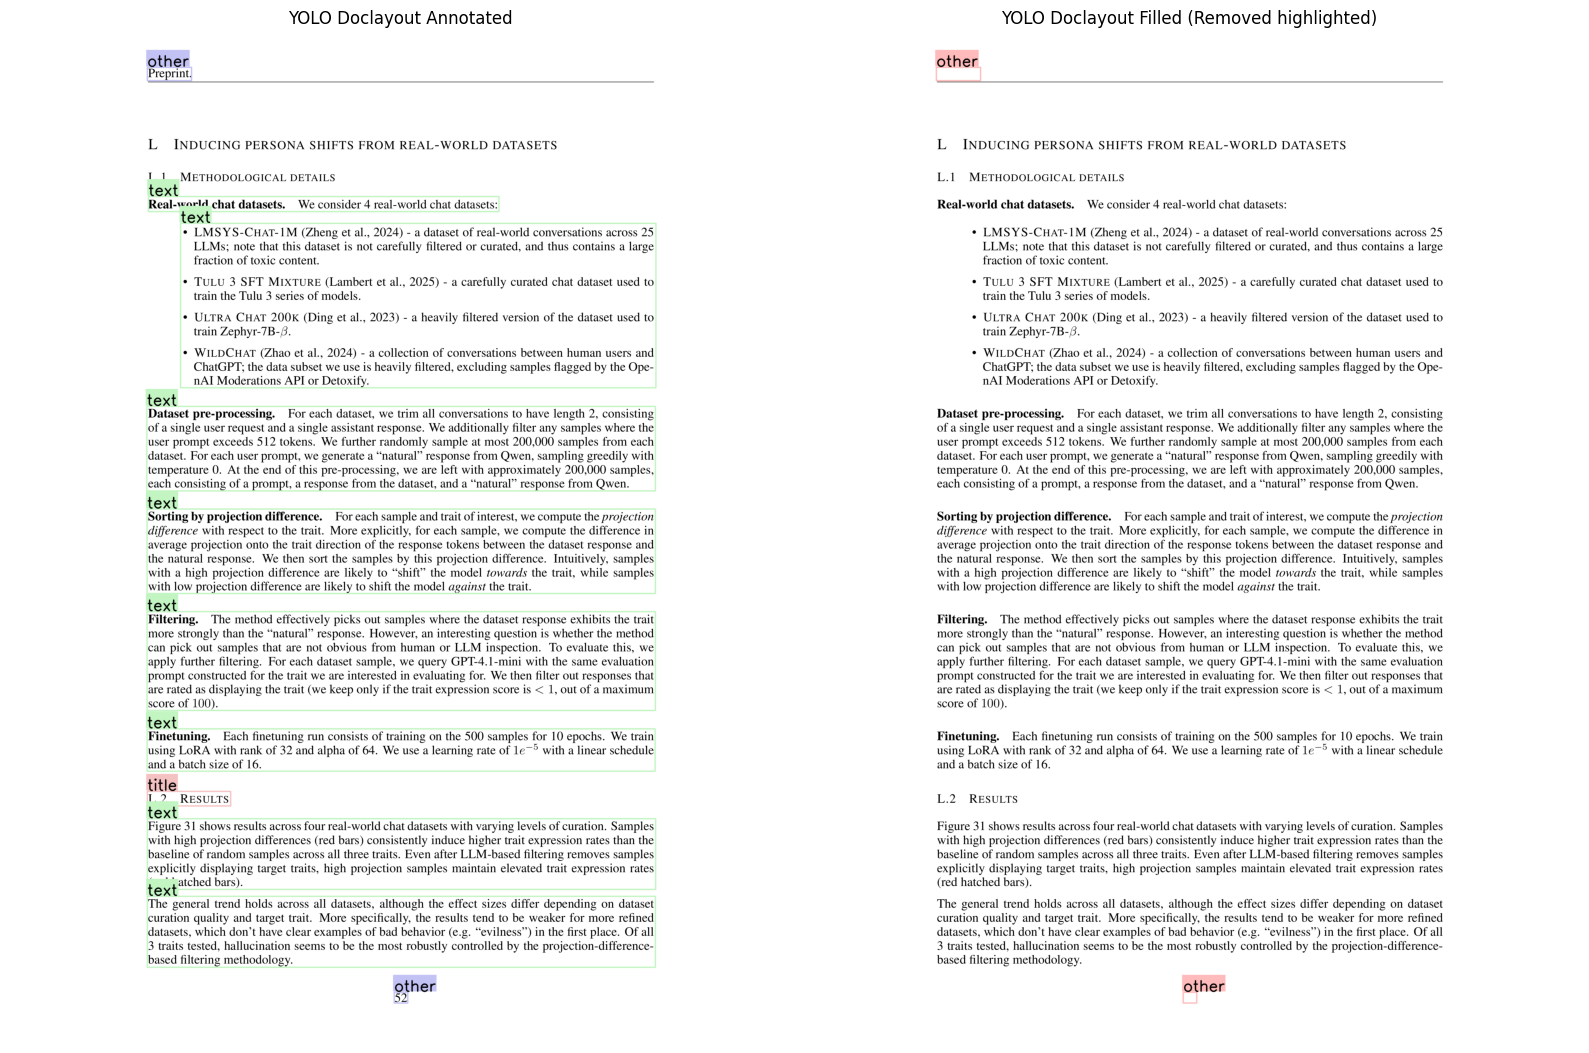

In [13]:
def get_filled_image_and_removed(
    image: np.ndarray,
    detections: list[Any],
    labels_to_include: list[str],
) -> tuple["np.ndarray", list[Any]]:
    """
    Generate an image with specified regions filled, and return removed detections.

    Args:
        image_path: Path to the image file.
        detections: List of DetectionResult objects.
        labels_to_include: List of label names to include for filling.

    Returns:
        Tuple of:
            - np.ndarray: Image with selected regions filled.
            - list[Any]: Detections that were removed (not included for filling).
    """
    filtered_detections = filter_detections(
        detections=detections,
        labels_to_include=labels_to_include,
    )
    regions = [det.bbox for det in filtered_detections]
    filled_image = fill_regions_with_color(
        image=image,
        regions=regions,  # type: ignore
    )
    return filled_image, filtered_detections


def plot_annotated_and_filled_with_removed(
    annotated_image: "np.ndarray",
    filled_image: "np.ndarray",
    removed_detections: list[Any],
    annotated_title: str,
    filled_title: str,
    figsize: tuple[int, int] = (16, 12),
) -> None:
    """
    Display annotated and filled images side by side, with removed elements annotated on the filled image.

    Args:
        annotated_image: Annotated image as a numpy array.
        filled_image: Image with filled regions as a numpy array.
        removed_detections: List of DetectionResult objects that were removed.
        annotated_title: Title for the annotated image.
        filled_title: Title for the filled image.
        figsize: Figure size for the plot.
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    axes[0].imshow(annotated_image)
    axes[1].imshow(filled_image)
    axes[0].set_title(annotated_title)
    axes[1].set_title(f"{filled_title} (Removed highlighted)")

    for ax in axes:
        ax.axis("off")

    # Annotate removed detections on the filled image
    img = NumpyAnnotator(
        image=filled_image,
        detections=removed_detections,
        line_color=(255, 0, 0),
        line_width=4,
        font_thickness=3,
    ).annotate()
    axes[1].imshow(img)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.01)
    plt.show()


page_image = "data/page_num.png"
for num in pages_to_extract:
    page_image = Path(f"data/page_{num}.png")
    page_image = load_rgb_image(page_image)

    detector = Detector(
        model_path=str(DEFAULT_YOLO_DOCLAYNET_PATH),
        backend=DetectionBackendEnum.YOLO_DOCLAYNET,
        settings=settings,
    )

    detections_doclaynet = detector.parse_layout(page_image)

    detector = Detector(
        model_path=str(DEFAULT_DOCLAYOUT_YOLO_PATH),
        backend=DetectionBackendEnum.DOCLAYOUT_YOLO,
        settings=settings,
    )

    detections_doclayout = detector.parse_layout(page_image)

    filled_image_doclaynet, removed_doclaynet = get_filled_image_and_removed(
        image=page_image,
        detections=detections_doclaynet,
        labels_to_include=LABELS_TO_FILL,
    )

    annotated_doclaynet = NumpyAnnotator(
        image=page_image,
        detections=detections_doclaynet,
        line_width=4,
        font_thickness=3,
    ).annotate()

    plot_annotated_and_filled_with_removed(
        annotated_image=annotated_doclaynet,
        filled_image=filled_image_doclaynet,
        removed_detections=removed_doclaynet,
        annotated_title="YOLO Doclaynet Annotated",
        filled_title="YOLO Doclaynet Filled",
    )

    filled_image_doclayout, removed_doclayout = get_filled_image_and_removed(
        image=page_image,
        detections=detections_doclayout,
        labels_to_include=LABELS_TO_FILL,
    )

    annotated_doclayout = NumpyAnnotator(
        image=page_image,
        detections=detections_doclayout,
        line_width=4,
        font_thickness=3,
    ).annotate()

    plot_annotated_and_filled_with_removed(
        annotated_image=annotated_doclayout,
        filled_image=filled_image_doclayout,
        removed_detections=removed_doclayout,
        annotated_title="YOLO Doclayout Annotated",
        filled_title="YOLO Doclayout Filled",
    )